# 01 - Data Overview & Exploratory Data Analysis
## Expedia Hotel Search Ranking

This notebook provides a comprehensive exploration of the Expedia hotel search dataset, covering:
1. Dataset shape & schema
2. Train/test temporal & structural checks
3. Missing value analysis
4. Continuous feature distributions
5. Categorical/discrete feature distributions
6. Cardinality & ID analysis
7. Outlier detection
8. Temporal patterns

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from src.config import TRAIN_FILE, TEST_FILE
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
SEED = 42

In [2]:
print("Loading training data...")
train = pd.read_csv(TRAIN_FILE, na_values="NULL")
print(f"Train shape: {train.shape}")

print("\nLoading test data...")
test = pd.read_csv(TEST_FILE, na_values="NULL")
print(f"Test shape: {test.shape}")

print(f"\nTrain: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test:  {test.shape[0]:,} rows x {test.shape[1]} columns")

Loading training data...


Train shape: (4958347, 54)

Loading test data...


Test shape: (4959183, 50)

Train: 4,958,347 rows x 54 columns
Test:  4,959,183 rows x 50 columns


## 1.1 Dataset Shape & Schema

In [3]:
# Column group categorization
def get_column_group(col):
    col_lower = col.lower()
    if col in ['srch_id', 'prop_id', 'site_id']:
        return 'ID'
    elif col in ['click_bool', 'booking_bool', 'gross_bookings_usd', 'position']:
        return 'Target'
    elif col.startswith('srch_') or col in ['date_time', 'random_bool']:
        return 'Search'
    elif col.startswith('visitor_'):
        return 'Visitor'
    elif col.startswith('prop_'):
        return 'Property'
    elif col.startswith('price') or col == 'orig_destination_distance':
        return 'Price'
    elif col.startswith('comp'):
        return 'Competitor'
    else:
        return 'Other'

# Build detailed column inventory for train
print("Building column inventory for training set...")
inventory_rows = []
for col in train.columns:
    n_missing = train[col].isnull().sum()
    pct_missing = n_missing / len(train) * 100
    n_unique = train[col].nunique()
    
    if pd.api.types.is_numeric_dtype(train[col]):
        col_min = train[col].min()
        col_max = train[col].max()
        col_mean = train[col].mean()
    else:
        col_min = str(train[col].min()) if not train[col].isnull().all() else np.nan
        col_max = str(train[col].max()) if not train[col].isnull().all() else np.nan
        col_mean = np.nan
    
    inventory_rows.append({
        'column_name': col,
        'group': get_column_group(col),
        'dtype': str(train[col].dtype),
        'n_unique': n_unique,
        'n_missing': n_missing,
        'pct_missing': f"{pct_missing:.2f}%",
        'min': col_min,
        'max': col_max,
        'mean': round(col_mean, 4) if pd.notna(col_mean) else np.nan,
    })

inventory = pd.DataFrame(inventory_rows)

# Style and display
group_colors = {
    'ID': 'background-color: #e6f3ff',
    'Search': 'background-color: #e6ffe6',
    'Visitor': 'background-color: #fff0e6',
    'Property': 'background-color: #f0e6ff',
    'Price': 'background-color: #ffe6e6',
    'Competitor': 'background-color: #e6ffff',
    'Other': 'background-color: #f5f5f5',
    'Target': 'background-color: #ffffe6',
}

def color_groups(row):
    color = group_colors.get(row['group'], '')
    return [color] * len(row)

styled = inventory.style.apply(color_groups, axis=1).set_caption("Training Set Column Inventory")
styled

Building column inventory for training set...


,column_name,group,dtype,n_unique,n_missing,pct_missing,min,max,mean
0,srch_id,ID,int64,199795,0,0.00%,1,332785,166366.561100
1,date_time,Search,object,198615,0,0.00%,2012-11-01 00:08:29,2013-06-30 23:58:24,nan
2,site_id,ID,int64,34,0,0.00%,1,34,9.953100
3,visitor_location_country_id,Visitor,int64,210,0,0.00%,1,231,175.340500
4,visitor_hist_starrating,Visitor,float64,312,4706481,94.92%,1.410000,5.000000,3.374300
5,visitor_hist_adr_usd,Visitor,float64,7799,4705359,94.90%,0.000000,1958.700000,176.022700
6,prop_country_id,Property,int64,172,0,0.00%,1,230,173.973900
7,prop_id,ID,int64,129113,0,0.00%,1,140821,70079.179500
8,prop_starrating,Property,int64,6,0,0.00%,0,5,3.180500
9,prop_review_score,Property,float64,10,7364,0.15%,0.000000,5.000000,3.777800


In [4]:
# Train vs Test comparison
print("Building train vs test comparison...")
train_only_cols = [c for c in train.columns if c not in test.columns]
test_only_cols = [c for c in test.columns if c not in train.columns]
shared_cols = [c for c in train.columns if c in test.columns]

print(f"Train-only columns ({len(train_only_cols)}): {train_only_cols}")
print(f"Test-only columns ({len(test_only_cols)}): {test_only_cols}")
print(f"Shared columns: {len(shared_cols)}")

# Side-by-side comparison for shared numeric columns
comparison_rows = []
for col in shared_cols:
    if not pd.api.types.is_numeric_dtype(train[col]):
        continue
    tr_unique = train[col].nunique()
    te_unique = test[col].nunique()
    tr_min = train[col].min()
    te_min = test[col].min()
    tr_max = train[col].max()
    te_max = test[col].max()
    tr_mean = train[col].mean()
    te_mean = test[col].mean()
    
    # Flag conditions
    flags = []
    if pd.notna(te_max) and pd.notna(tr_max) and te_max > tr_max:
        flags.append("test_max > train_max")
    if pd.notna(tr_mean) and pd.notna(te_mean) and tr_mean != 0:
        pct_diff = abs(te_mean - tr_mean) / abs(tr_mean) * 100
        if pct_diff > 10:
            flags.append(f"mean_diff={pct_diff:.1f}%")
    
    comparison_rows.append({
        'column': col,
        'train_n_unique': tr_unique,
        'test_n_unique': te_unique,
        'train_min': round(tr_min, 4) if pd.notna(tr_min) else np.nan,
        'test_min': round(te_min, 4) if pd.notna(te_min) else np.nan,
        'train_max': round(tr_max, 4) if pd.notna(tr_max) else np.nan,
        'test_max': round(te_max, 4) if pd.notna(te_max) else np.nan,
        'train_mean': round(tr_mean, 4) if pd.notna(tr_mean) else np.nan,
        'test_mean': round(te_mean, 4) if pd.notna(te_mean) else np.nan,
        'flags': ', '.join(flags) if flags else '',
    })

comparison_df = pd.DataFrame(comparison_rows)

# Highlight flagged rows
def highlight_flags(row):
    if row['flags']:
        return ['background-color: #ffcccc'] * len(row)
    return [''] * len(row)

comparison_df.style.apply(highlight_flags, axis=1).set_caption("Train vs Test Comparison (Shared Numeric Columns)")

Building train vs test comparison...
Train-only columns (4): ['position', 'click_bool', 'gross_bookings_usd', 'booking_bool']
Test-only columns (0): []
Shared columns: 50


,column,train_n_unique,test_n_unique,train_min,test_min,train_max,test_max,train_mean,test_mean,flags
0,srch_id,199795,199549,1.000000,1.000000,332785.000000,332787.000000,166366.561100,166646.023900,test_max > train_max
1,site_id,34,34,1.000000,1.000000,34.000000,34.000000,9.953100,9.979200,
2,visitor_location_country_id,210,210,1.000000,1.000000,231.000000,231.000000,175.340500,175.250400,
3,visitor_hist_starrating,312,311,1.410000,1.000000,5.000000,5.000000,3.374300,3.374900,
4,visitor_hist_adr_usd,7799,7843,0.000000,0.000000,1958.700000,2768.930000,176.022700,177.150700,test_max > train_max
5,prop_country_id,172,167,1.000000,1.000000,230.000000,230.000000,173.973900,173.837100,
6,prop_id,129113,129438,1.000000,1.000000,140821.000000,140821.000000,70079.179500,70081.112200,
7,prop_starrating,6,6,0.000000,0.000000,5.000000,5.000000,3.180500,3.182500,
8,prop_review_score,10,10,0.000000,0.000000,5.000000,5.000000,3.777800,3.777600,
9,prop_brand_bool,2,2,0.000000,0.000000,1.000000,1.000000,0.634700,0.633900,


## 1.2 Train/Test Temporal & Structural Checks

Parsing date_time columns...


Train date range: 2012-11-01 to 2013-06-30


Test date range:  2012-11-01 to 2013-06-30


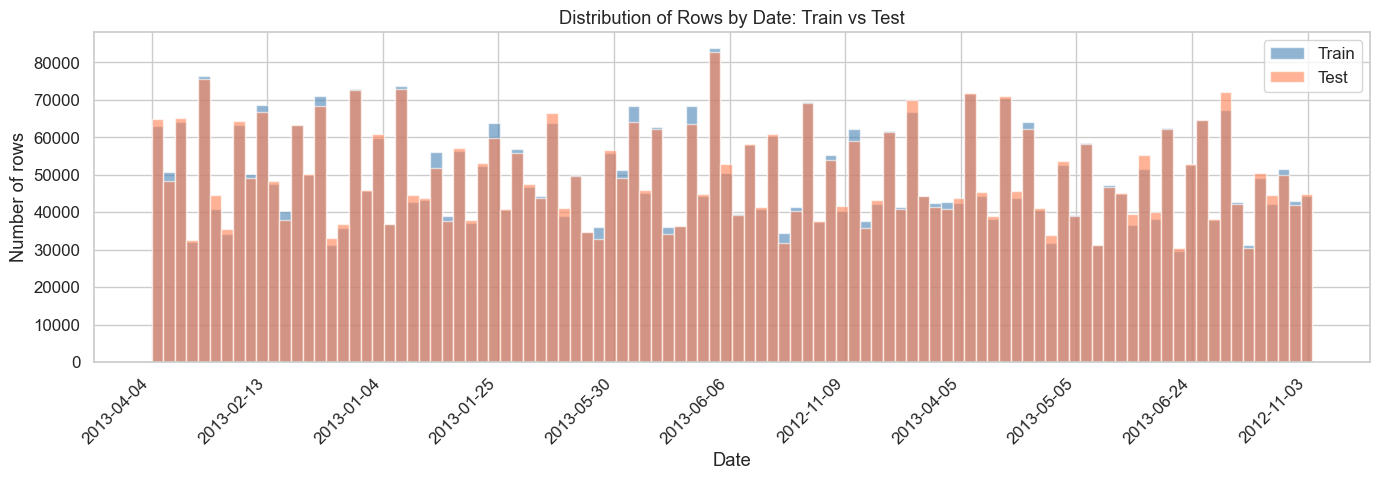


Date overlap: 242 days in common
Conclusion: Train and test cover largely the SAME period (random split likely).


In [5]:
# Temporal split analysis
print("Parsing date_time columns...")
train['date_time_parsed'] = pd.to_datetime(train['date_time'])
test['date_time_parsed'] = pd.to_datetime(test['date_time'])

train_dates = train['date_time_parsed'].dt.date
test_dates = test['date_time_parsed'].dt.date

print(f"Train date range: {train_dates.min()} to {train_dates.max()}")
print(f"Test date range:  {test_dates.min()} to {test_dates.max()}")

# Overlapping histograms of dates by day
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(train['date_time_parsed'].dt.to_period('D').astype(str), bins=100, 
        alpha=0.6, label='Train', color='steelblue')
ax.hist(test['date_time_parsed'].dt.to_period('D').astype(str), bins=100, 
        alpha=0.6, label='Test', color='coral')
ax.set_xlabel('Date')
ax.set_ylabel('Number of rows')
ax.set_title('Distribution of Rows by Date: Train vs Test')
ax.legend()
# Show fewer x-tick labels to avoid overlap
tick_positions = ax.get_xticks()
ax.set_xticks(tick_positions[::max(1, len(tick_positions) // 10)])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Determine split type
train_max = train_dates.max()
test_min = test_dates.min()
overlap = (train_dates.max() >= test_dates.min()) and (test_dates.max() >= train_dates.min())
if not overlap:
    print("\nConclusion: Test is from a LATER period (temporal split, no overlap).")
elif overlap:
    train_date_set = set(train_dates.unique())
    test_date_set = set(test_dates.unique())
    intersection = train_date_set & test_date_set
    print(f"\nDate overlap: {len(intersection)} days in common")
    if len(intersection) > 0.5 * max(len(train_date_set), len(test_date_set)):
        print("Conclusion: Train and test cover largely the SAME period (random split likely).")
    else:
        print("Conclusion: Partial temporal overlap.")

In [6]:
# Test random_bool check
print("=== random_bool in test ===")
if 'random_bool' in test.columns:
    print(f"random_bool EXISTS in test set")
    print(f"\nValue counts:")
    print(test['random_bool'].value_counts())
    print(f"\nProportion of random_bool=1: {test['random_bool'].mean():.4f}")
    print("\nImplication: random_bool indicates whether results were randomly sorted.")
    print("For evaluation, only rows where random_bool=1 are used by Expedia,")
    print("ensuring unbiased position-independent evaluation.")
else:
    print("random_bool does NOT exist in test set.")

=== random_bool in test ===
random_bool EXISTS in test set

Value counts:
random_bool
0    3486708
1    1472475
Name: count, dtype: int64

Proportion of random_bool=1: 0.2969

Implication: random_bool indicates whether results were randomly sorted.
For evaluation, only rows where random_bool=1 are used by Expedia,
ensuring unbiased position-independent evaluation.


In [7]:
# Prop_id overlap analysis
print("=== Property ID Overlap ===")
train_props = set(train['prop_id'].unique())
test_props = set(test['prop_id'].unique())
intersection_props = train_props & test_props
train_only_props = train_props - test_props
test_only_props = test_props - train_props

print(f"Unique properties in train: {len(train_props):,}")
print(f"Unique properties in test:  {len(test_props):,}")
print(f"Properties in both:         {len(intersection_props):,}")
print(f"Properties only in train:   {len(train_only_props):,}")
print(f"Properties only in test:    {len(test_only_props):,}")
print(f"\n{len(intersection_props) / len(test_props) * 100:.1f}% of test properties appear in training")
print(f"{len(test_only_props):,} properties in test never seen in training")
print("\nThis is critical for aggregate feature reliability: property-level statistics")
print("computed on training data may not be available for all test properties.")

=== Property ID Overlap ===


Unique properties in train: 129,113
Unique properties in test:  129,438
Properties in both:         121,665
Properties only in train:   7,448
Properties only in test:    7,773

94.0% of test properties appear in training
7,773 properties in test never seen in training

This is critical for aggregate feature reliability: property-level statistics
computed on training data may not be available for all test properties.


In [8]:
# Repeat/near-duplicate searches
print("=== Repeat / Near-Duplicate Searches ===")
print("Grouping by (visitor_location_country_id, srch_destination_id, srch_length_of_stay,")
print("             srch_adults_count, srch_children_count, srch_room_count)...")

group_cols = ['visitor_location_country_id', 'srch_destination_id', 
              'srch_length_of_stay', 'srch_adults_count', 'srch_children_count', 'srch_room_count']

search_groups = train.groupby(group_cols)['srch_id'].nunique().reset_index()
search_groups.columns = group_cols + ['n_unique_searches']
repeat_groups = search_groups[search_groups['n_unique_searches'] > 1]

print(f"\nTotal unique search parameter combinations: {len(search_groups):,}")
print(f"Combinations with >1 unique srch_id: {len(repeat_groups):,} ({len(repeat_groups)/len(search_groups)*100:.1f}%)")
print(f"\nTop 10 most repeated search parameter combos:")
top_repeats = repeat_groups.nlargest(10, 'n_unique_searches')
print(top_repeats.to_string(index=False))

print(f"\nTotal searches involved in repeat groups: {repeat_groups['n_unique_searches'].sum():,}")
print(f"out of {train['srch_id'].nunique():,} total unique searches")
print("\nThese repeated patterns could enable session-level or user-intent features.")

=== Repeat / Near-Duplicate Searches ===
Grouping by (visitor_location_country_id, srch_destination_id, srch_length_of_stay,
             srch_adults_count, srch_children_count, srch_room_count)...



Total unique search parameter combinations: 114,511
Combinations with >1 unique srch_id: 23,846 (20.8%)

Top 10 most repeated search parameter combos:
 visitor_location_country_id  srch_destination_id  srch_length_of_stay  srch_adults_count  srch_children_count  srch_room_count  n_unique_searches
                         219                 8192                    2                  2                    0                1                410
                         219                 8192                    3                  2                    0                1                253
                         219                26067                    1                  2                    0                1                242
                         219                 8192                    1                  2                    0                1                239
                         219                 4562                    1                  2                    0   

### Key Findings - Section 1.2

- **Temporal split**: Examine whether train/test overlap temporally or if test is a future holdout.
- **random_bool**: Controls whether the search results were randomly ordered. Critical for debiasing position effects in training. Only random_bool=1 rows in test matter for evaluation.
- **Property overlap**: Any properties unseen in training will lack aggregate historical features -- need fallback strategies.
- **Repeat searches**: Many search parameter combinations appear multiple times, suggesting session-level or repeat-visitor features could be valuable.

## 1.3 Missing Value Analysis

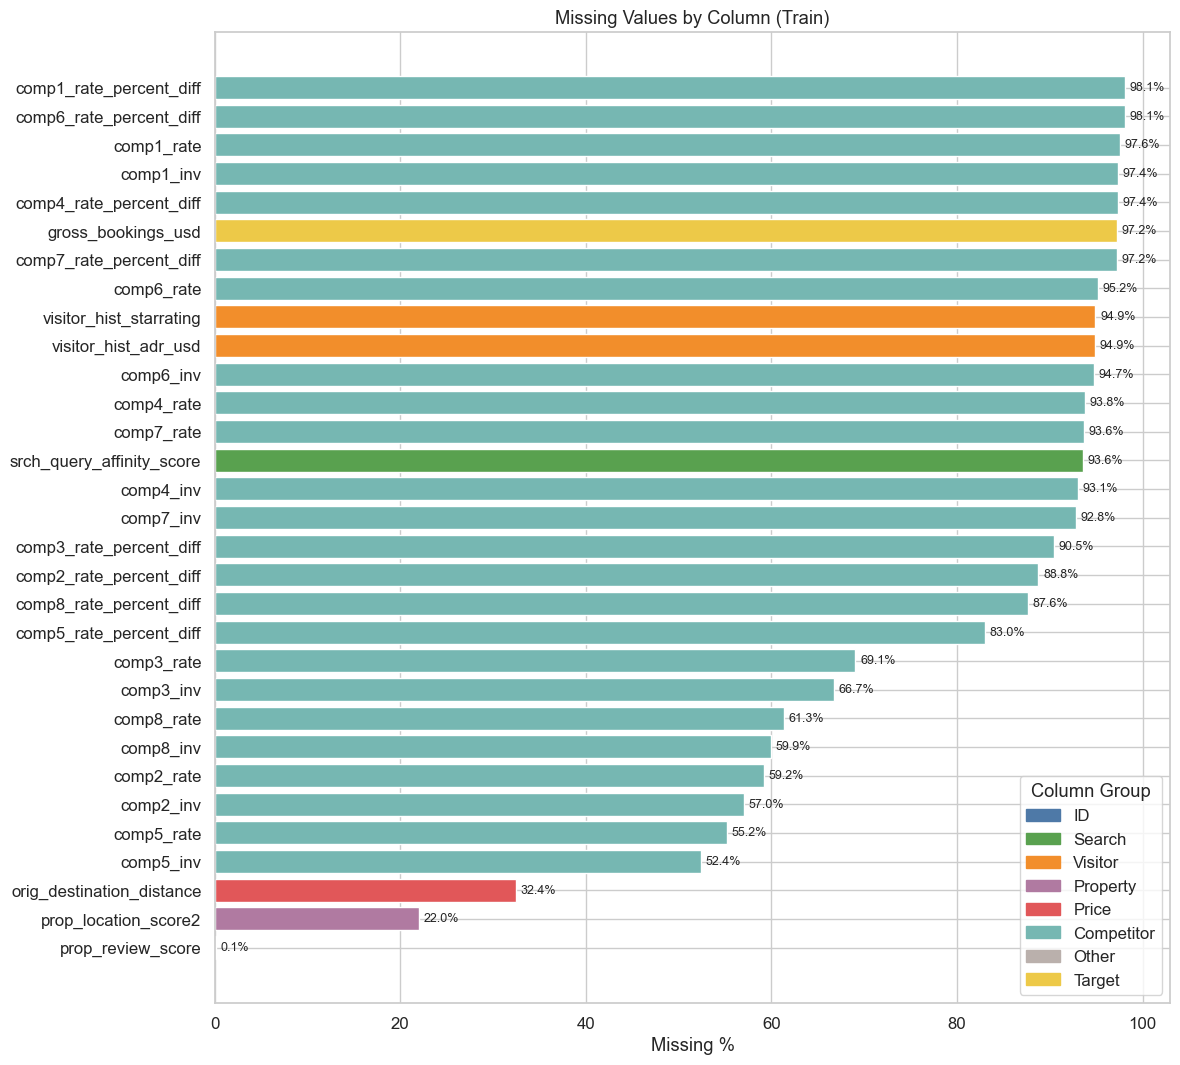

In [9]:
# Horizontal bar chart of missing % per column
missing_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

# Color by column group
colors = [{'ID': '#4e79a7', 'Search': '#59a14f', 'Visitor': '#f28e2b', 
           'Property': '#b07aa1', 'Price': '#e15759', 'Competitor': '#76b7b2',
           'Other': '#bab0ac', 'Target': '#edc948'}.get(get_column_group(col), '#bab0ac') 
          for col in missing_pct.index]

fig, ax = plt.subplots(figsize=(12, max(8, len(missing_pct) * 0.35)))
bars = ax.barh(range(len(missing_pct)), missing_pct.values, color=colors)
ax.set_yticks(range(len(missing_pct)))
ax.set_yticklabels(missing_pct.index)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column (Train)')

# Add percentage labels
for i, (val, name) in enumerate(zip(missing_pct.values, missing_pct.index)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

# Legend for groups
from matplotlib.patches import Patch
group_color_map = {'ID': '#4e79a7', 'Search': '#59a14f', 'Visitor': '#f28e2b', 
                   'Property': '#b07aa1', 'Price': '#e15759', 'Competitor': '#76b7b2',
                   'Other': '#bab0ac', 'Target': '#edc948'}
legend_patches = [Patch(color=c, label=g) for g, c in group_color_map.items()]
ax.legend(handles=legend_patches, loc='lower right', title='Column Group')

plt.tight_layout()
plt.show()

Computing missingness co-occurrence matrix...


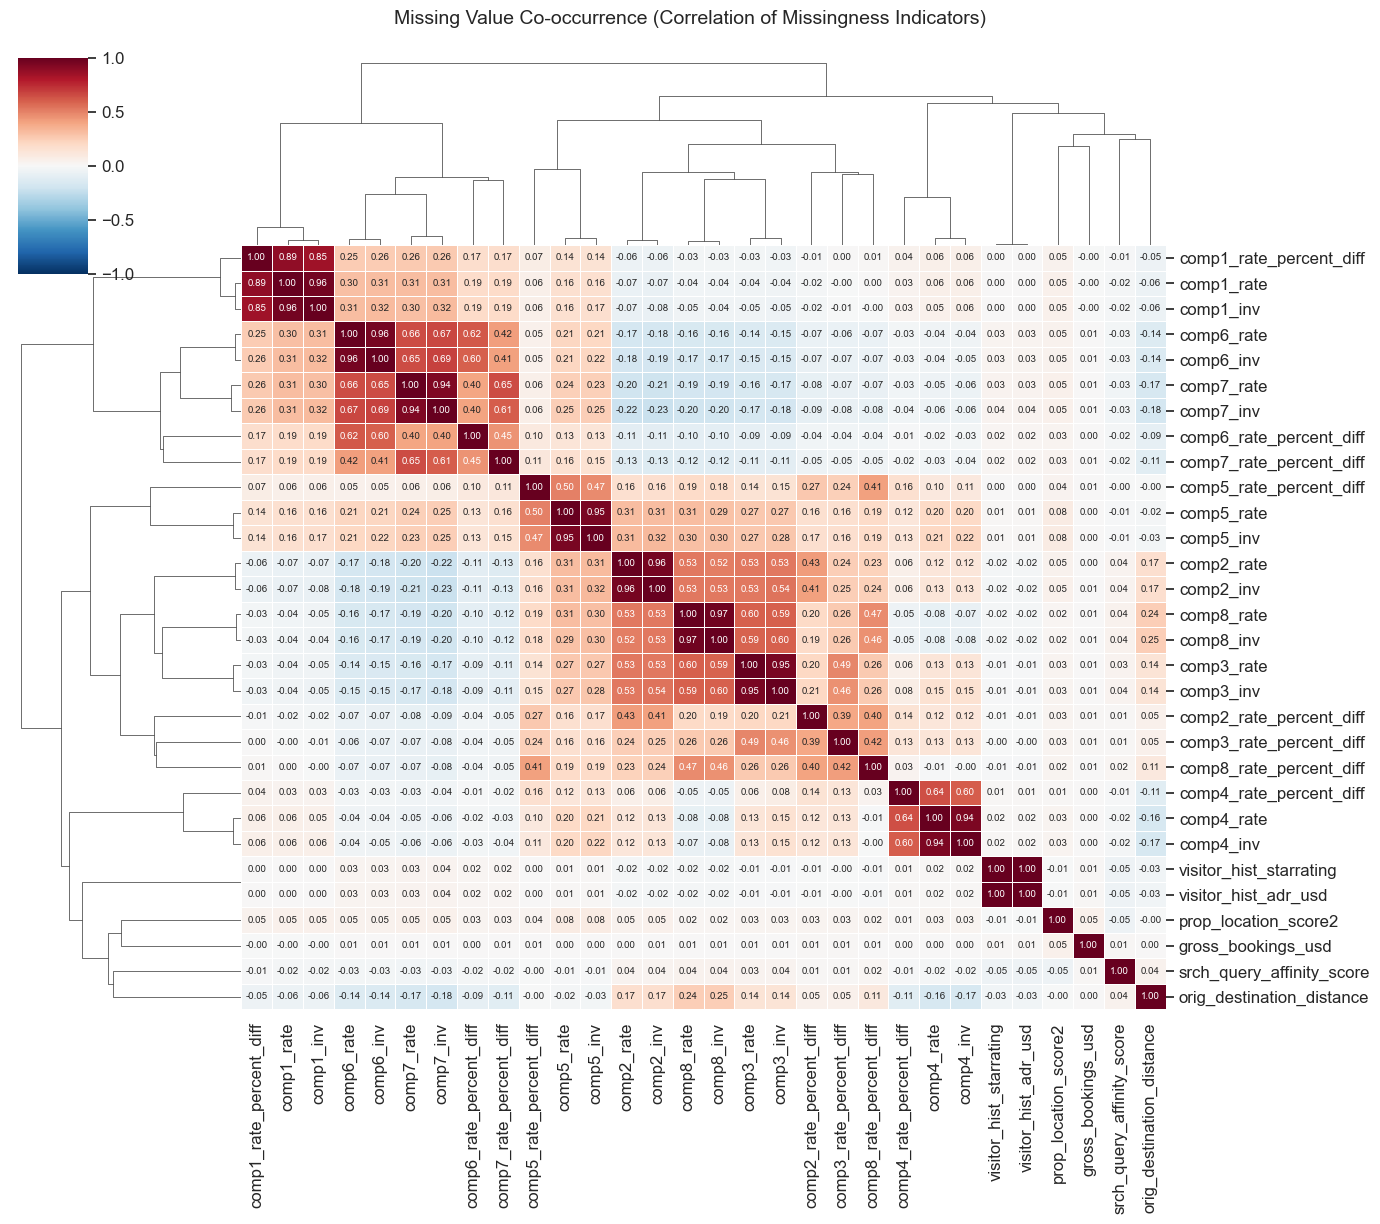

In [10]:
# Missing value co-occurrence (correlation of missingness indicators)
print("Computing missingness co-occurrence matrix...")
cols_with_missing = [col for col in train.columns 
                     if train[col].isnull().mean() > 0.01 and col != 'date_time_parsed']

if len(cols_with_missing) > 1:
    miss_indicators = train[cols_with_missing].isnull().astype(int)
    miss_corr = miss_indicators.corr()
    
    g = sns.clustermap(miss_corr, cmap='RdBu_r', center=0, 
                       figsize=(14, 12), linewidths=0.5,
                       annot=True, fmt='.2f', annot_kws={'size': 7},
                       vmin=-1, vmax=1)
    g.fig.suptitle('Missing Value Co-occurrence (Correlation of Missingness Indicators)', 
                   y=1.02, fontsize=14)
    plt.show()
else:
    print("Not enough columns with >1% missing to compute co-occurrence.")

In [11]:
# Informative missingness test
print("Testing whether missingness is informative (affects click/booking rate)...")
cols_to_test = [col for col in train.columns 
                if train[col].isnull().mean() > 0.01 
                and col not in ['date_time', 'date_time_parsed', 'click_bool', 'booking_bool', 'gross_bookings_usd']]

info_rows = []
for col in cols_to_test:
    is_missing = train[col].isnull()
    
    click_present = train.loc[~is_missing, 'click_bool'].mean() * 100
    click_missing = train.loc[is_missing, 'click_bool'].mean() * 100
    book_present = train.loc[~is_missing, 'booking_bool'].mean() * 100
    book_missing = train.loc[is_missing, 'booking_bool'].mean() * 100
    
    # Chi-squared test for click_bool
    contingency = pd.crosstab(is_missing, train['click_bool'])
    chi2, p_val, _, _ = stats.chi2_contingency(contingency)
    
    info_rows.append({
        'column': col,
        'pct_missing': f"{train[col].isnull().mean()*100:.1f}%",
        'click_rate_present': f"{click_present:.2f}%",
        'click_rate_missing': f"{click_missing:.2f}%",
        'click_diff_pp': round(click_missing - click_present, 2),
        'book_rate_present': f"{book_present:.2f}%",
        'book_rate_missing': f"{book_missing:.2f}%",
        'book_diff_pp': round(book_missing - book_present, 2),
        'chi2_pvalue': f"{p_val:.2e}",
    })

info_df = pd.DataFrame(info_rows)

# Highlight rows with >0.5 pp difference in either click or book rate
def highlight_informative(row):
    if abs(row['click_diff_pp']) > 0.5 or abs(row['book_diff_pp']) > 0.5:
        return ['background-color: #ffffb3'] * len(row)
    return [''] * len(row)

info_df.style.apply(highlight_informative, axis=1).set_caption(
    "Informative Missingness: Click/Booking rates by presence/absence (yellow = >0.5pp diff)")

Testing whether missingness is informative (affects click/booking rate)...


,column,pct_missing,click_rate_present,click_rate_missing,click_diff_pp,book_rate_present,book_rate_missing,book_diff_pp,chi2_pvalue
0,visitor_hist_starrating,94.9%,4.42%,4.48%,0.050000,3.61%,2.75%,-0.860000,2.05e-01
1,visitor_hist_adr_usd,94.9%,4.43%,4.48%,0.050000,3.61%,2.75%,-0.860000,2.43e-01
2,prop_location_score2,22.0%,5.05%,2.45%,-2.600000,3.20%,1.33%,-1.880000,0.00e+00
3,srch_query_affinity_score,93.6%,4.43%,4.48%,0.050000,3.43%,2.75%,-0.680000,2.08e-01
4,orig_destination_distance,32.4%,4.40%,4.64%,0.240000,2.80%,2.78%,-0.020000,1.57e-33
5,comp1_rate,97.6%,4.51%,4.47%,-0.030000,2.64%,2.79%,0.150000,6.13e-01
6,comp1_inv,97.4%,4.44%,4.48%,0.040000,2.59%,2.80%,0.210000,4.95e-01
7,comp1_rate_percent_diff,98.1%,4.49%,4.47%,-0.010000,2.65%,2.79%,0.140000,8.43e-01
8,comp2_rate,59.2%,4.35%,4.56%,0.210000,2.89%,2.72%,-0.170000,9.39e-30
9,comp2_inv,57.0%,4.37%,4.56%,0.190000,2.90%,2.71%,-0.190000,3.82e-24


=== Competitor Missingness Breakdown ===



competitor rate_avail_% inv_avail_% rate_pct_diff_avail_%
     comp1         2.4%        2.6%                  1.9%
     comp2        40.8%       43.0%                 11.2%
     comp3        30.9%       33.3%                  9.5%
     comp4         6.2%        6.9%                  2.6%
     comp5        44.8%       47.6%                 17.0%
     comp6         4.8%        5.3%                  1.9%
     comp7         6.4%        7.2%                  2.8%
     comp8        38.7%       40.1%                 12.4%


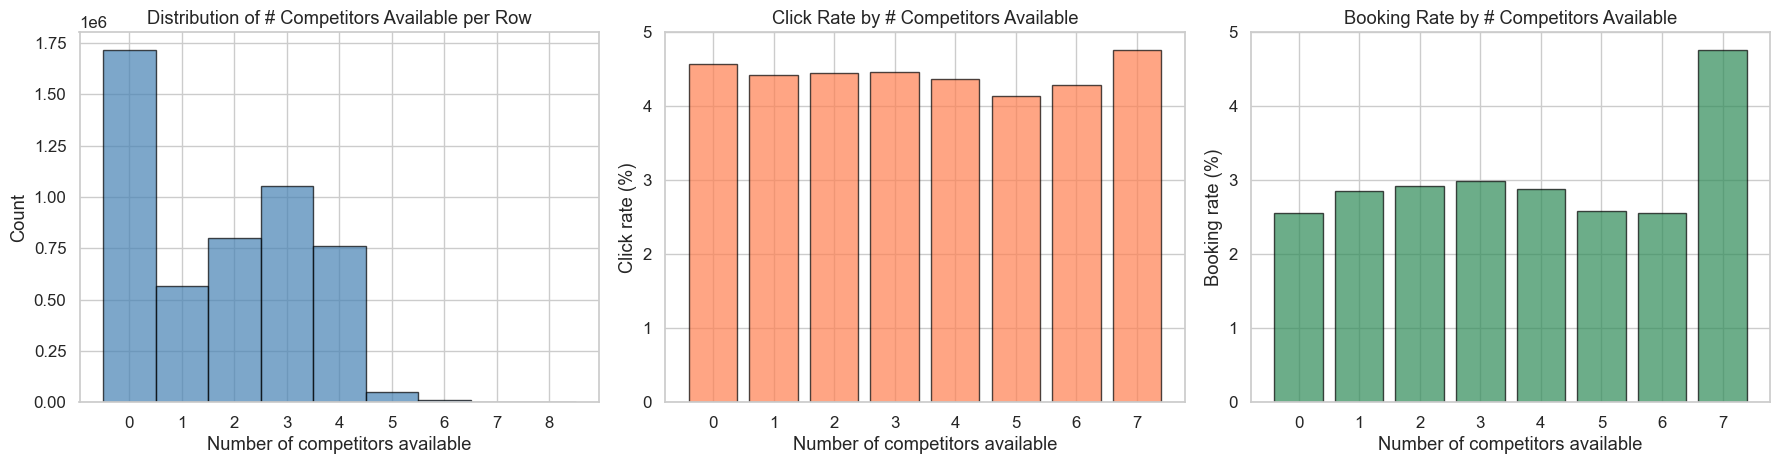

In [12]:
# Competitor missingness breakdown
print("=== Competitor Missingness Breakdown ===\n")

comp_avail_rows = []
for i in range(1, 9):
    rate_col = f'comp{i}_rate'
    inv_col = f'comp{i}_inv'
    diff_col = f'comp{i}_rate_percent_diff'
    
    row = {'competitor': f'comp{i}'}
    for col, label in [(rate_col, 'rate'), (inv_col, 'inv'), (diff_col, 'rate_pct_diff')]:
        if col in train.columns:
            avail = (1 - train[col].isnull().mean()) * 100
            row[f'{label}_avail_%'] = f"{avail:.1f}%"
        else:
            row[f'{label}_avail_%'] = 'N/A'
    comp_avail_rows.append(row)

comp_avail_df = pd.DataFrame(comp_avail_rows)
print(comp_avail_df.to_string(index=False))

# n_comp_available: number of comp{i}_rate that are not null per row
comp_rate_cols = [f'comp{i}_rate' for i in range(1, 9) if f'comp{i}_rate' in train.columns]
train['n_comp_available'] = train[comp_rate_cols].notna().sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of n_comp_available
axes[0].hist(train['n_comp_available'], bins=range(0, len(comp_rate_cols) + 2), 
             edgecolor='black', alpha=0.7, color='steelblue', align='left')
axes[0].set_xlabel('Number of competitors available')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of # Competitors Available per Row')
axes[0].set_xticks(range(0, len(comp_rate_cols) + 1))

# Click rate by n_comp_available
click_by_comp = train.groupby('n_comp_available')['click_bool'].mean() * 100
axes[1].bar(click_by_comp.index, click_by_comp.values, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of competitors available')
axes[1].set_ylabel('Click rate (%)')
axes[1].set_title('Click Rate by # Competitors Available')

# Booking rate by n_comp_available
book_by_comp = train.groupby('n_comp_available')['booking_bool'].mean() * 100
axes[2].bar(book_by_comp.index, book_by_comp.values, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Number of competitors available')
axes[2].set_ylabel('Booking rate (%)')
axes[2].set_title('Booking Rate by # Competitors Available')

plt.tight_layout()
plt.show()

### Key Findings - Section 1.3

- **Missing value patterns**: Competitor columns are the most heavily missing (often >90%). Visitor history and query affinity scores also have substantial missingness.
- **Co-occurrence**: Competitor columns tend to be missing together (same competitor's rate/inv/diff are correlated). Visitor history columns (starrating + adr_usd) are also co-missing.
- **Informative missingness**: If click/booking rates differ significantly between present vs missing rows, the missingness itself is a useful feature. Consider adding `is_missing_X` binary indicators.
- **Competitor availability**: The number of available competitors per row varies widely and may itself be predictive of click/booking behavior.

## 1.4 Continuous Feature Distributions

In [13]:
# 10% sample for distribution plots
print("Taking 10% sample for distribution plots...")
sample = train.sample(frac=0.1, random_state=SEED)
print(f"Sample size: {len(sample):,} rows")

Taking 10% sample for distribution plots...


Sample size: 495,835 rows


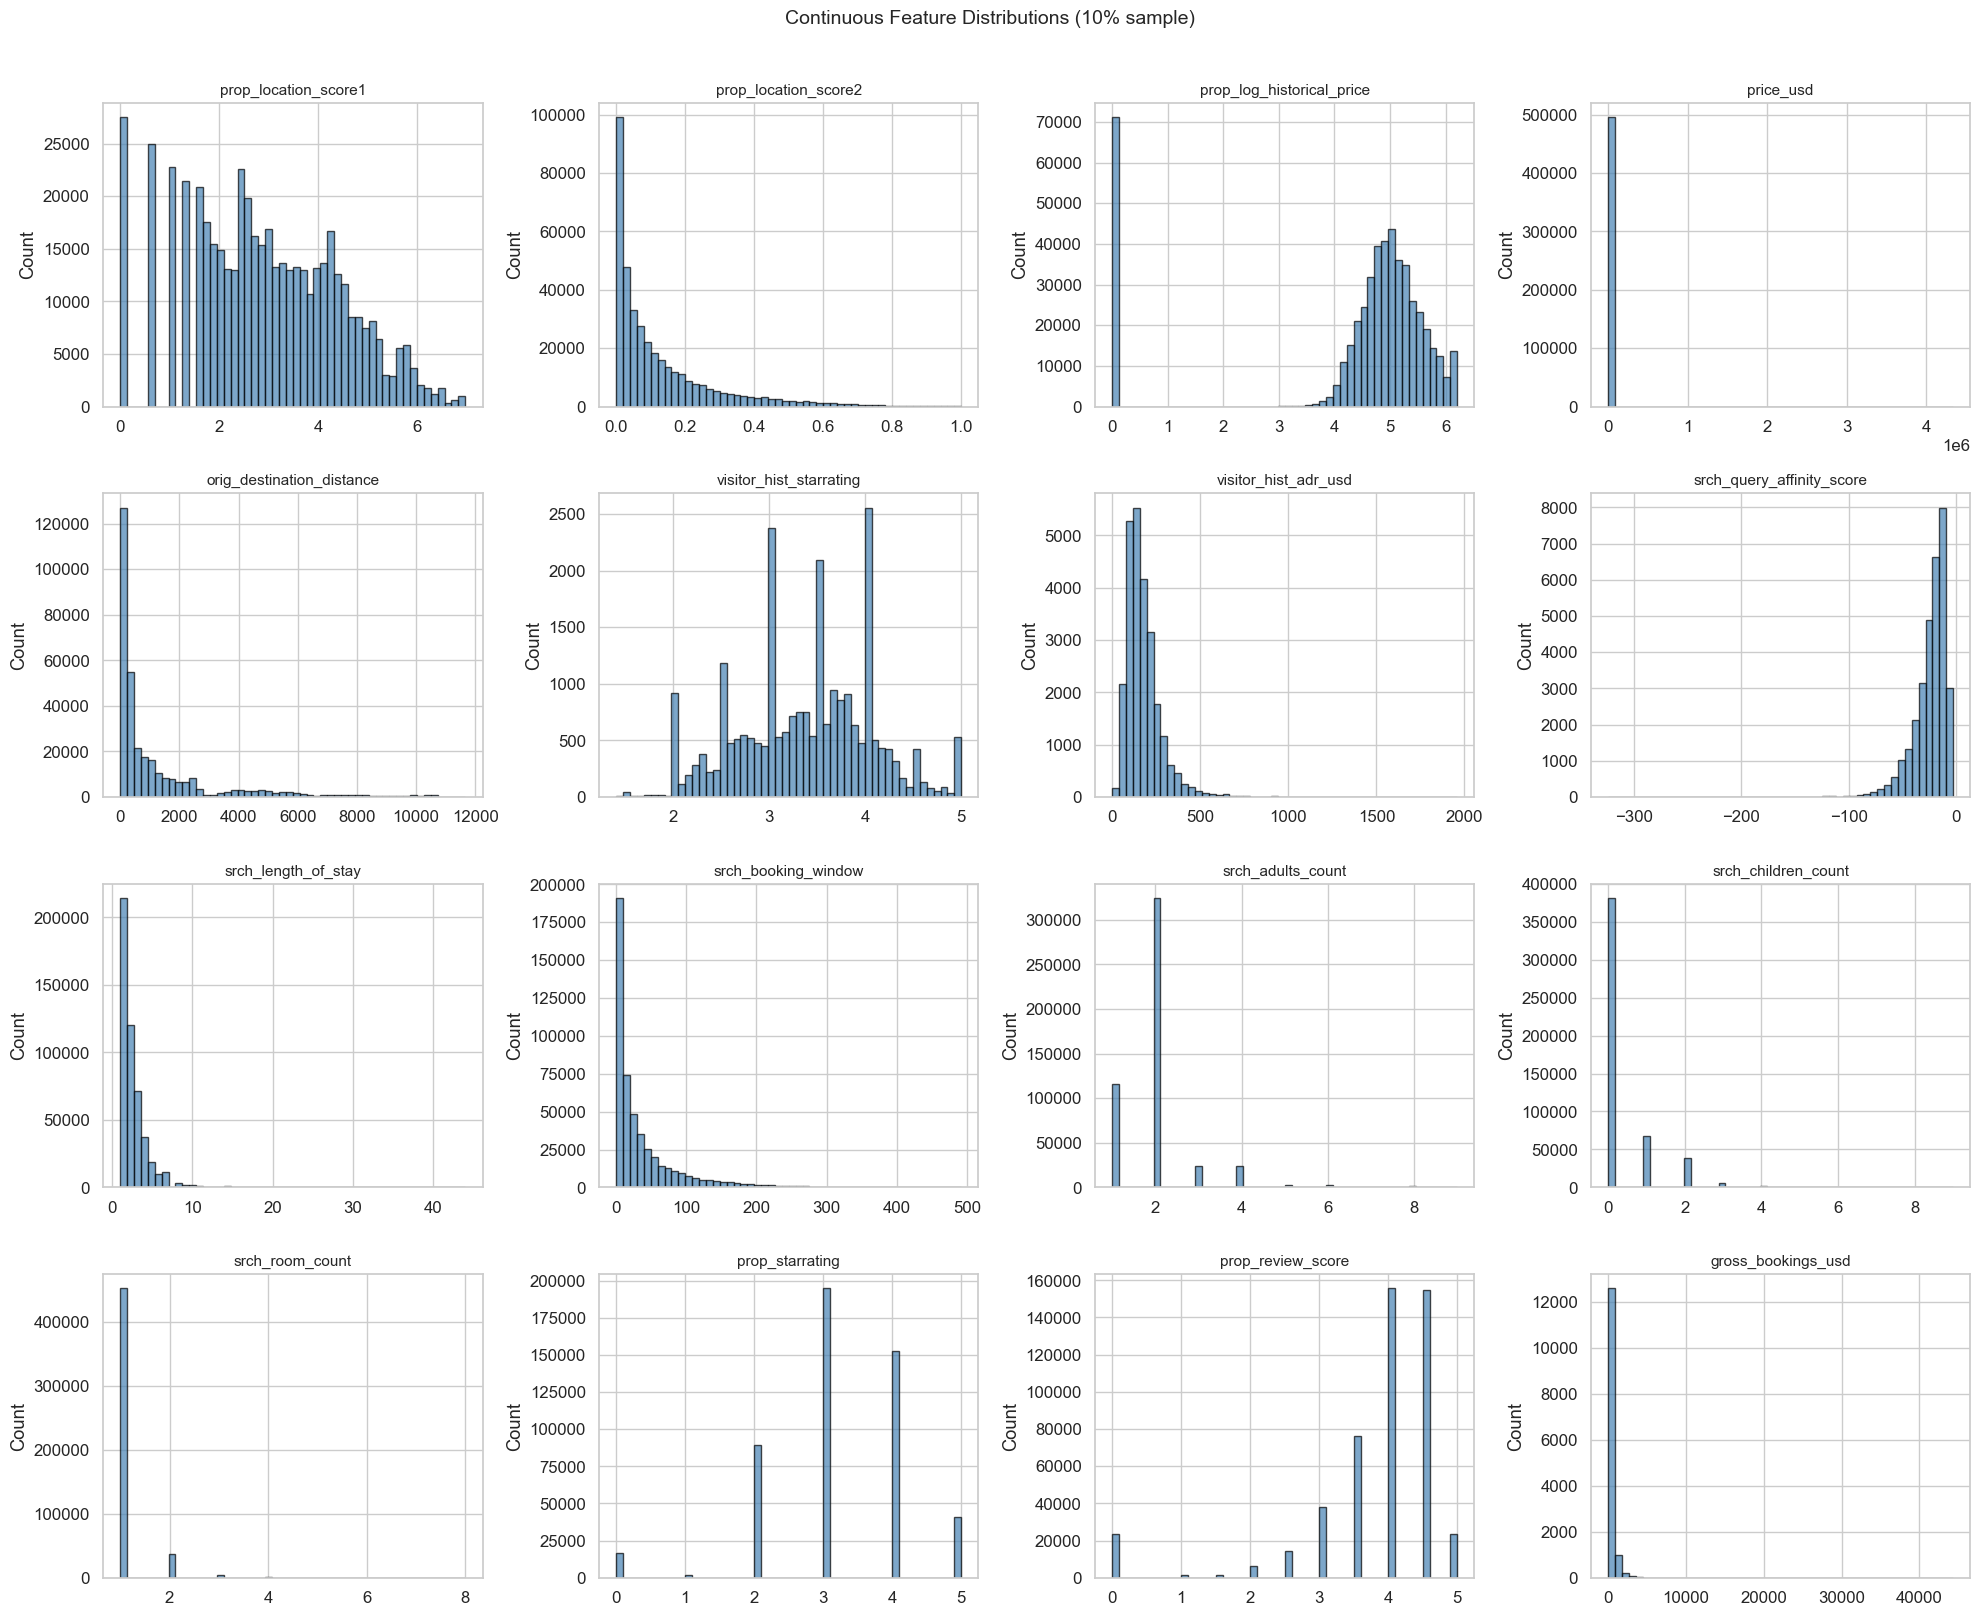

In [14]:
# Histogram grid for continuous features
cont_features = [
    'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd',
    'orig_destination_distance', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'srch_query_affinity_score',
    'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count',
    'srch_room_count', 'prop_starrating', 'prop_review_score', 'gross_bookings_usd'
]
# Filter to columns that exist
cont_features = [c for c in cont_features if c in sample.columns]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes_flat = axes.flatten()

for i, col in enumerate(cont_features):
    ax = axes_flat[i]
    data = sample[col].dropna()
    if len(data) > 0:
        ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

# Hide unused subplots
for j in range(len(cont_features), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Continuous Feature Distributions (10% sample)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_25541/433062958.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(star_groups, labels=[str(int(s)) for s in star_labels],


Prices above 99th percentile (600): 4,932 rows (0.99%)


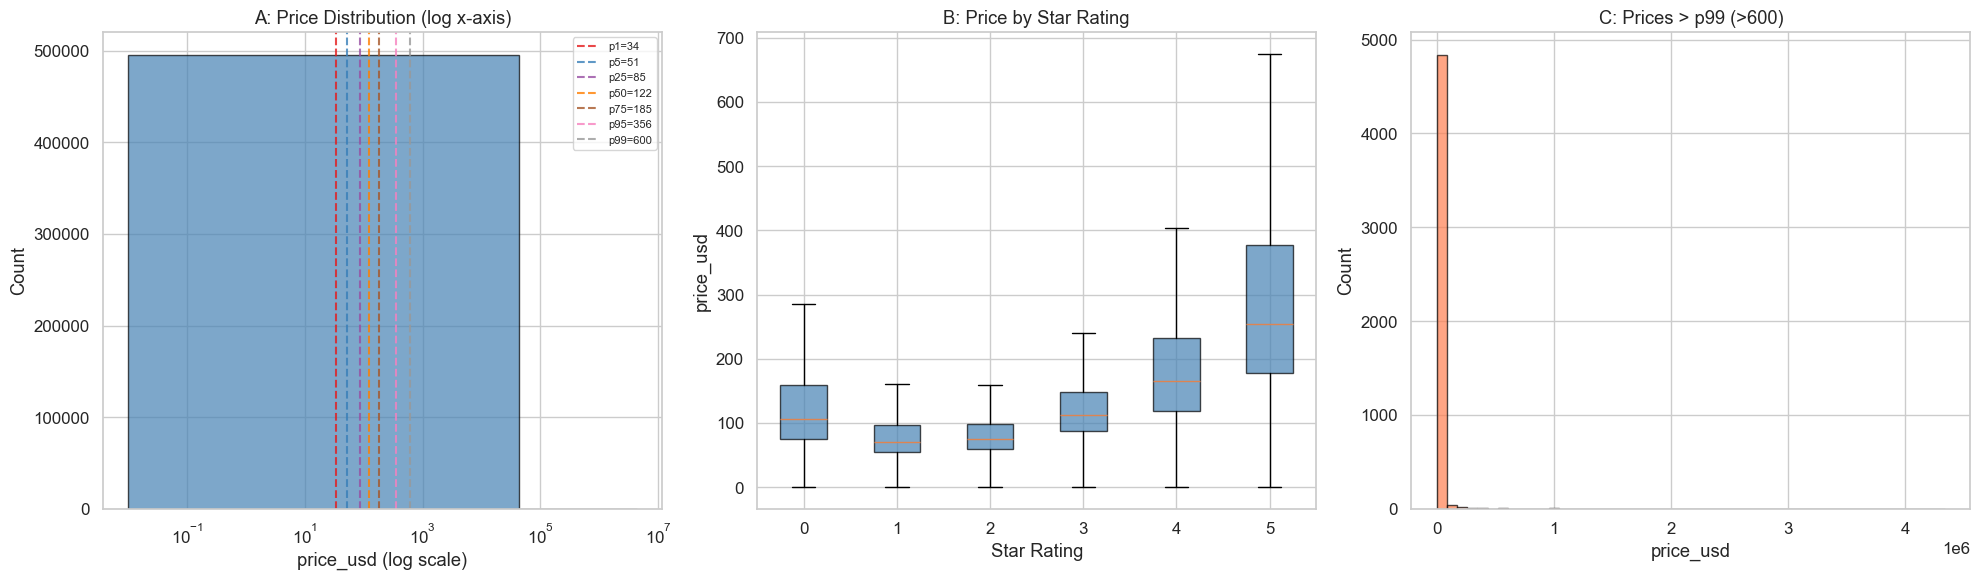

In [15]:
# Price deep-dive (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel A: Histogram of price_usd with log x-axis and percentile lines
price_data = sample['price_usd'].dropna()
price_data_pos = price_data[price_data > 0]

ax = axes[0]
ax.hist(price_data_pos, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('price_usd (log scale)')
ax.set_ylabel('Count')
ax.set_title('A: Price Distribution (log x-axis)')

# Add percentile lines
percentiles = [1, 5, 25, 50, 75, 95, 99]
colors_p = plt.cm.Set1(np.linspace(0, 1, len(percentiles)))
for pct, color in zip(percentiles, colors_p):
    val = np.percentile(price_data_pos, pct)
    ax.axvline(val, color=color, linestyle='--', alpha=0.8, linewidth=1.5, 
               label=f'p{pct}={val:.0f}')
ax.legend(fontsize=8, loc='upper right')

# Panel B: Box plot of price_usd by prop_starrating
ax = axes[1]
star_data = sample[['price_usd', 'prop_starrating']].dropna()
star_data = star_data[star_data['price_usd'] > 0]
star_groups = [group['price_usd'].values for name, group in star_data.groupby('prop_starrating')]
star_labels = sorted(star_data['prop_starrating'].unique())
bp = ax.boxplot(star_groups, labels=[str(int(s)) for s in star_labels], 
                patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_xlabel('Star Rating')
ax.set_ylabel('price_usd')
ax.set_title('B: Price by Star Rating')

# Panel C: Histogram of prices above 99th percentile
ax = axes[2]
p99 = np.percentile(price_data, 99)
extreme_prices = price_data[price_data > p99]
ax.hist(extreme_prices, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('price_usd')
ax.set_ylabel('Count')
ax.set_title(f'C: Prices > p99 (>{p99:.0f})')
print(f"Prices above 99th percentile ({p99:.0f}): {len(extreme_prices):,} rows ({len(extreme_prices)/len(price_data)*100:.2f}%)")

plt.tight_layout()
plt.show()

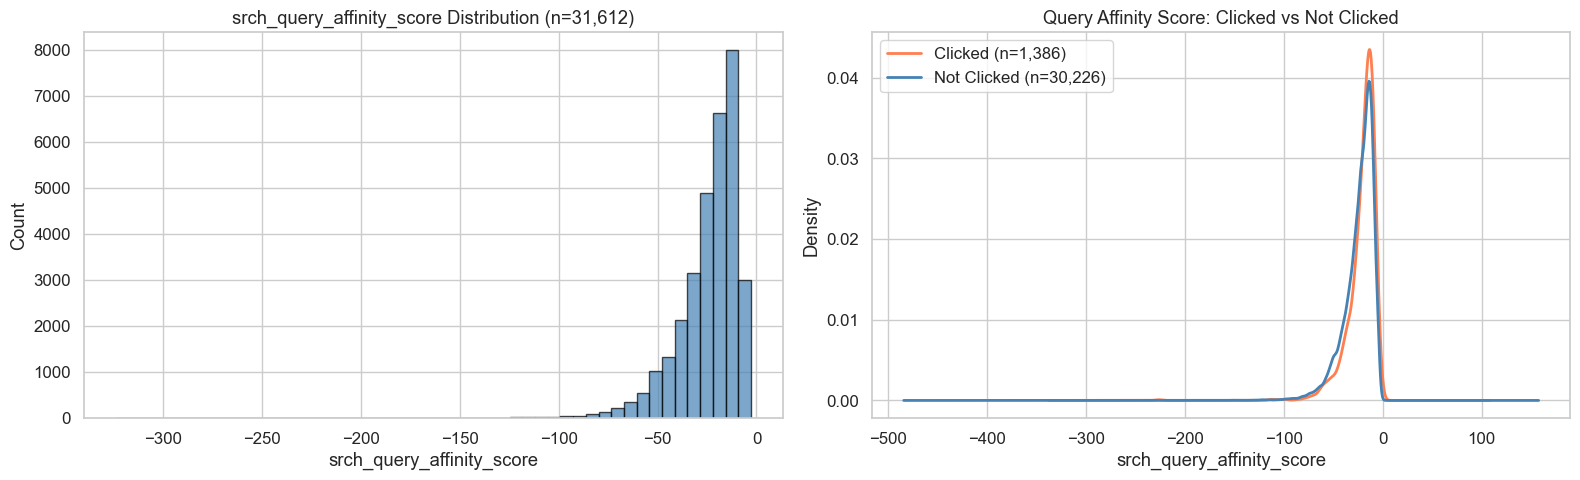

In [16]:
# srch_query_affinity_score: histogram + KDE for clicked vs not-clicked
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of non-null values
ax = axes[0]
affinity_data = sample['srch_query_affinity_score'].dropna()
ax.hist(affinity_data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('srch_query_affinity_score')
ax.set_ylabel('Count')
ax.set_title(f'srch_query_affinity_score Distribution (n={len(affinity_data):,})')

# KDE overlay for clicked vs not-clicked
ax = axes[1]
clicked = sample[sample['click_bool'] == 1]['srch_query_affinity_score'].dropna()
not_clicked = sample[sample['click_bool'] == 0]['srch_query_affinity_score'].dropna()
if len(clicked) > 10 and len(not_clicked) > 10:
    clicked.plot.kde(ax=ax, label=f'Clicked (n={len(clicked):,})', color='coral', linewidth=2)
    not_clicked.plot.kde(ax=ax, label=f'Not Clicked (n={len(not_clicked):,})', color='steelblue', linewidth=2)
    ax.set_xlabel('srch_query_affinity_score')
    ax.set_ylabel('Density')
    ax.set_title('Query Affinity Score: Clicked vs Not Clicked')
    ax.legend()

plt.tight_layout()
plt.show()

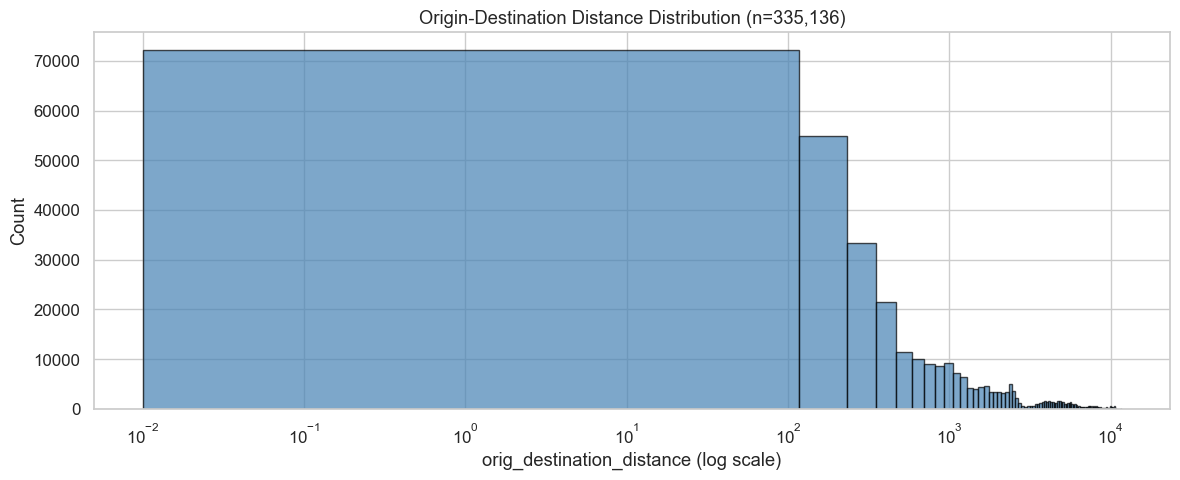

In [17]:
# orig_destination_distance: histogram with log x-axis
fig, ax = plt.subplots(figsize=(12, 5))
dist_data = sample['orig_destination_distance'].dropna()
dist_data_pos = dist_data[dist_data > 0]
ax.hist(dist_data_pos, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('orig_destination_distance (log scale)')
ax.set_ylabel('Count')
ax.set_title(f'Origin-Destination Distance Distribution (n={len(dist_data_pos):,})')
plt.tight_layout()
plt.show()

### Key Findings - Section 1.4

- **Price**: Highly right-skewed with extreme outliers. Log-transform is recommended. Price varies significantly by star rating, as expected.
- **srch_query_affinity_score**: Mostly negative values (log-scale scores). Distribution differs between clicked and non-clicked rows, suggesting predictive power.
- **orig_destination_distance**: Spans several orders of magnitude (log-normal shape). Many searches are for nearby properties, but a long tail exists for distant travel.
- **Visitor history features**: Available for only a subset of visitors (repeat users). When present, they provide strong signals about user preferences.
- **prop_log_historical_price**: Centered around ~4 (exp(4) ~ $55). Properties with extreme historical prices may need special treatment.

## 1.5 Categorical/Discrete Feature Distributions

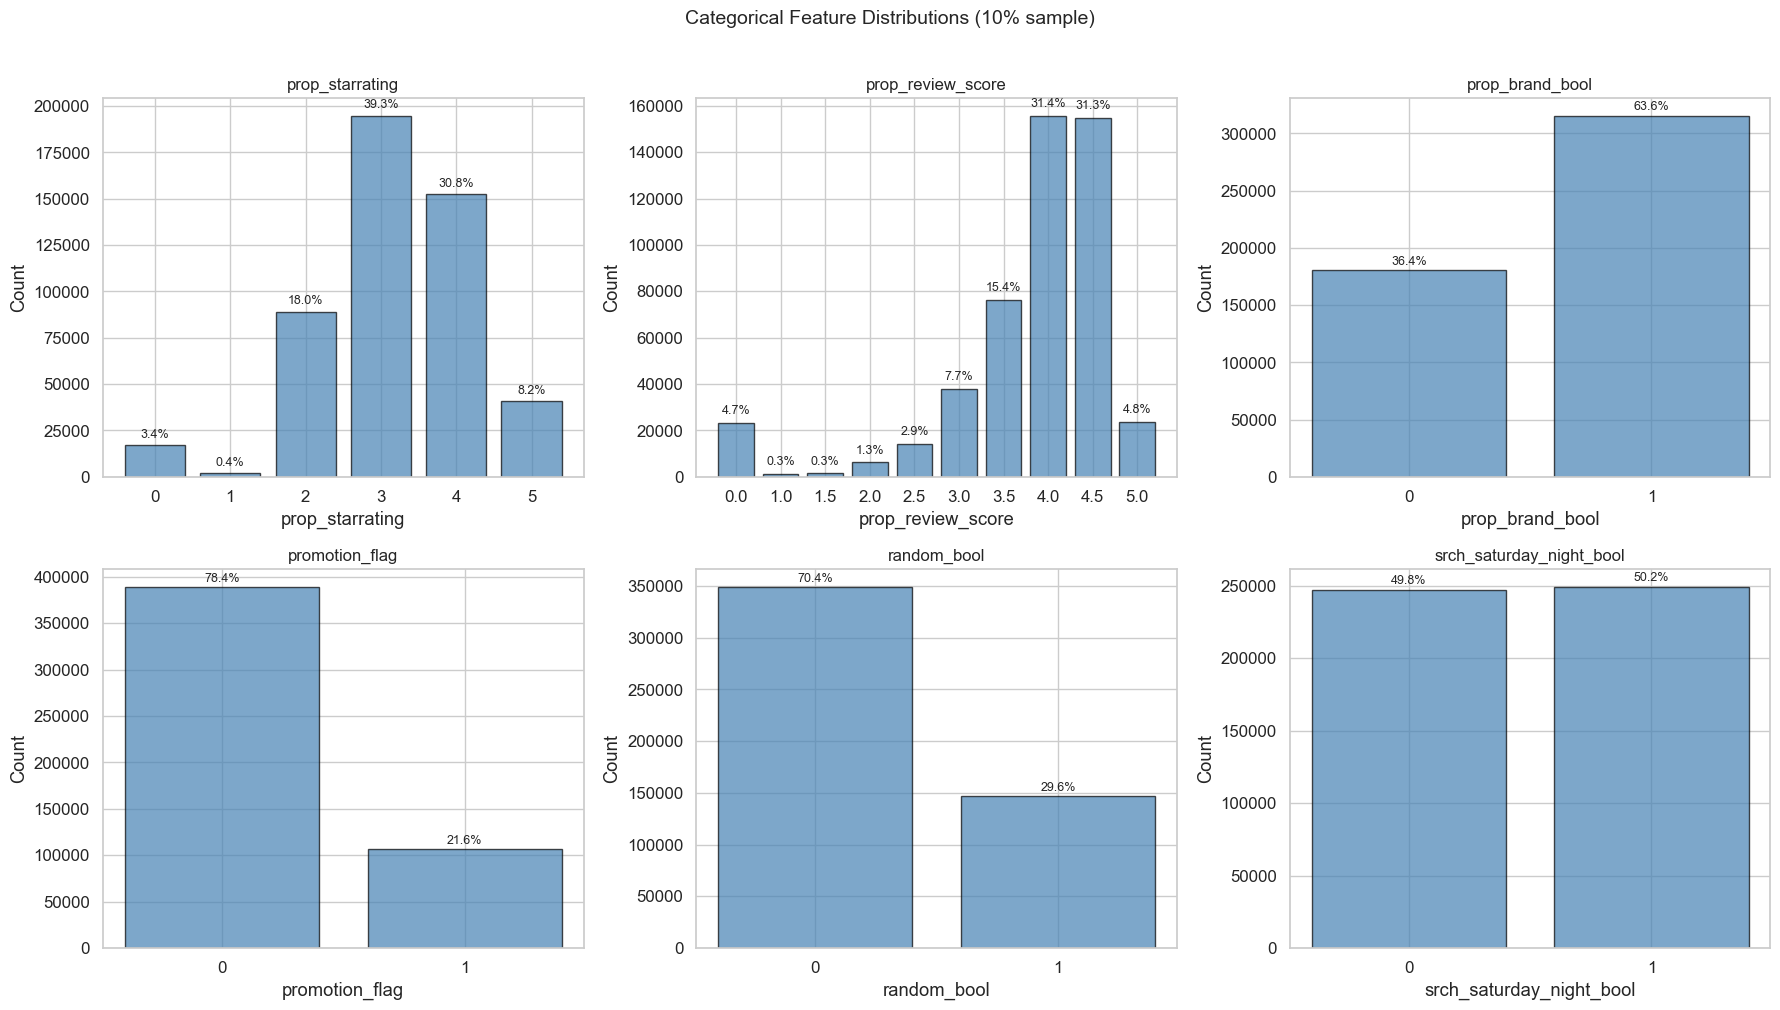

In [18]:
# 2x3 subplot grid for categorical features
cat_features = ['prop_starrating', 'prop_review_score', 'prop_brand_bool', 
                'promotion_flag', 'random_bool', 'srch_saturday_night_bool']
cat_features = [c for c in cat_features if c in sample.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes_flat[i]
    vc = sample[col].value_counts().sort_index()
    bars = ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    
    # Annotate percentages
    total = vc.sum()
    for bar, val in zip(bars, vc.values):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005, 
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# Hide unused subplots
for j in range(len(cat_features), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Categorical Feature Distributions (10% sample)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

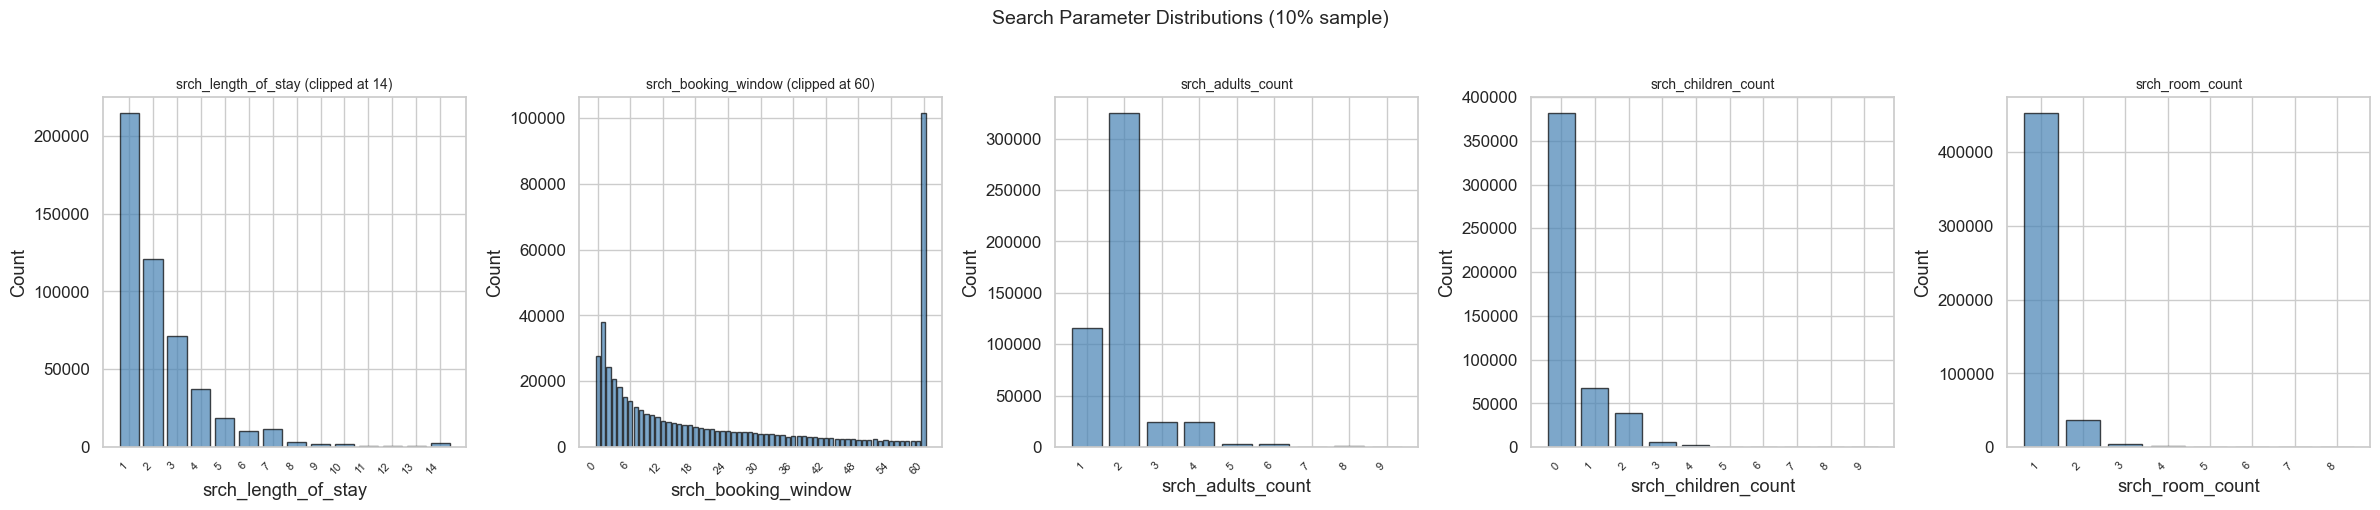

In [19]:
# Search parameter distributions
search_params = ['srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 
                 'srch_children_count', 'srch_room_count']

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for i, col in enumerate(search_params):
    ax = axes[i]
    data = sample[col].dropna()
    
    # Clip for display
    if col == 'srch_length_of_stay':
        data_display = data.clip(upper=14)
        clip_note = " (clipped at 14)"
    elif col == 'srch_booking_window':
        data_display = data.clip(upper=60)
        clip_note = " (clipped at 60)"
    else:
        data_display = data
        clip_note = ""
    
    vc = data_display.value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}{clip_note}', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    # Reduce x-tick labels if too many
    if len(vc) > 15:
        tick_pos = ax.get_xticks()
        ax.set_xticks(tick_pos[::max(1, len(tick_pos) // 10)])
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

fig.suptitle('Search Parameter Distributions (10% sample)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Key Findings - Section 1.5

- **Star rating**: Most properties are 3-star. Star rating 0 may indicate unrated properties.
- **Review score**: Concentrated around 3-4. Score of 0 may indicate no reviews.
- **Brand**: Most properties are non-branded. Branded properties may have higher visibility.
- **Promotion flag**: Small fraction of listings are promoted -- could be a strong signal.
- **random_bool**: Roughly balanced between random and non-random result ordering.
- **Search parameters**: Most stays are 1-3 nights, 1-2 adults, 0 children, 1 room. Long stays and large groups are rare.

## 1.6 Cardinality & ID Analysis

=== Hotels per Search (group size) ===
count    199795.000000
mean         24.817173
std           9.113335
min           5.000000
25%          18.000000
50%          29.000000
75%          32.000000
max          38.000000
dtype: float64

Is group size constant? False
Group size range: 5 to 38
Most common group sizes: 32    29935
33    26341
31    20007
30    11058
34     9562
Name: count, dtype: int64


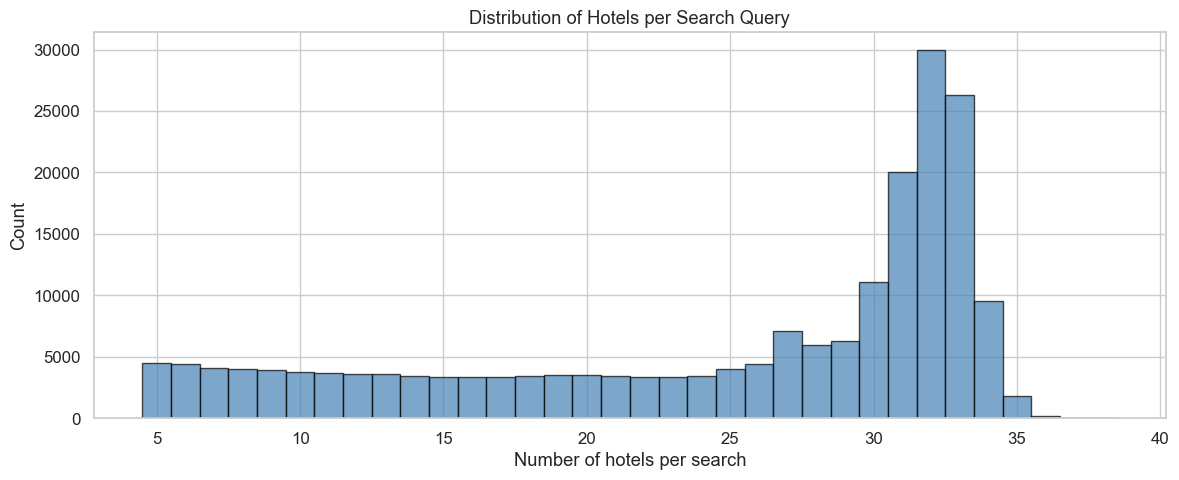

In [20]:
# Hotels per search
print("=== Hotels per Search (group size) ===")
hotels_per_search = train.groupby('srch_id').size()
print(hotels_per_search.describe())
print(f"\nIs group size constant? {hotels_per_search.nunique() == 1}")
if hotels_per_search.nunique() > 1:
    print(f"Group size range: {hotels_per_search.min()} to {hotels_per_search.max()}")
    print(f"Most common group sizes: {hotels_per_search.value_counts().head()}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(hotels_per_search, bins=range(hotels_per_search.min(), hotels_per_search.max() + 2),
        edgecolor='black', alpha=0.7, color='steelblue', align='left')
ax.set_xlabel('Number of hotels per search')
ax.set_ylabel('Count')
ax.set_title('Distribution of Hotels per Search Query')
plt.tight_layout()
plt.show()

=== Property Frequency ===


count    129113.000000
mean         38.403158
std          81.888119
min           1.000000
25%           4.000000
50%          12.000000
75%          40.000000
max        2357.000000
dtype: float64

Top 10 most frequent properties:
prop_id
104517    2357
124342    2355
68420     2285
40279     2275
134154    2257
137997    2247
59781     2245
60846     2237
77089     2230
49656     2230
dtype: int64


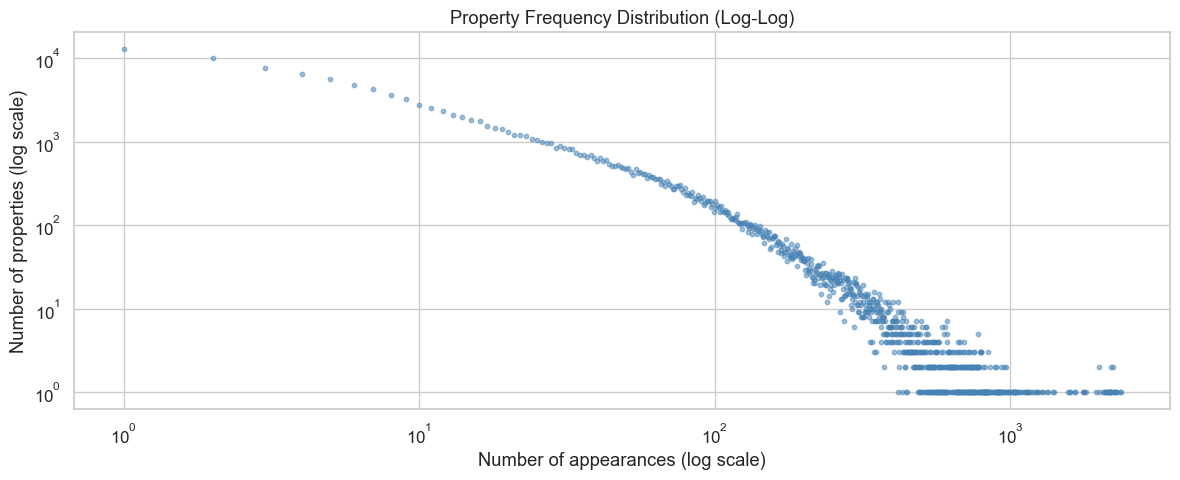

In [21]:
# Property frequency
print("=== Property Frequency ===")
prop_freq = train.groupby('prop_id').size().sort_values(ascending=False)
print(prop_freq.describe())
print(f"\nTop 10 most frequent properties:")
print(prop_freq.head(10))

fig, ax = plt.subplots(figsize=(12, 5))
# Log-log histogram
freq_counts = prop_freq.value_counts().sort_index()
ax.scatter(freq_counts.index, freq_counts.values, s=10, alpha=0.5, color='steelblue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of appearances (log scale)')
ax.set_ylabel('Number of properties (log scale)')
ax.set_title('Property Frequency Distribution (Log-Log)')
plt.tight_layout()
plt.show()

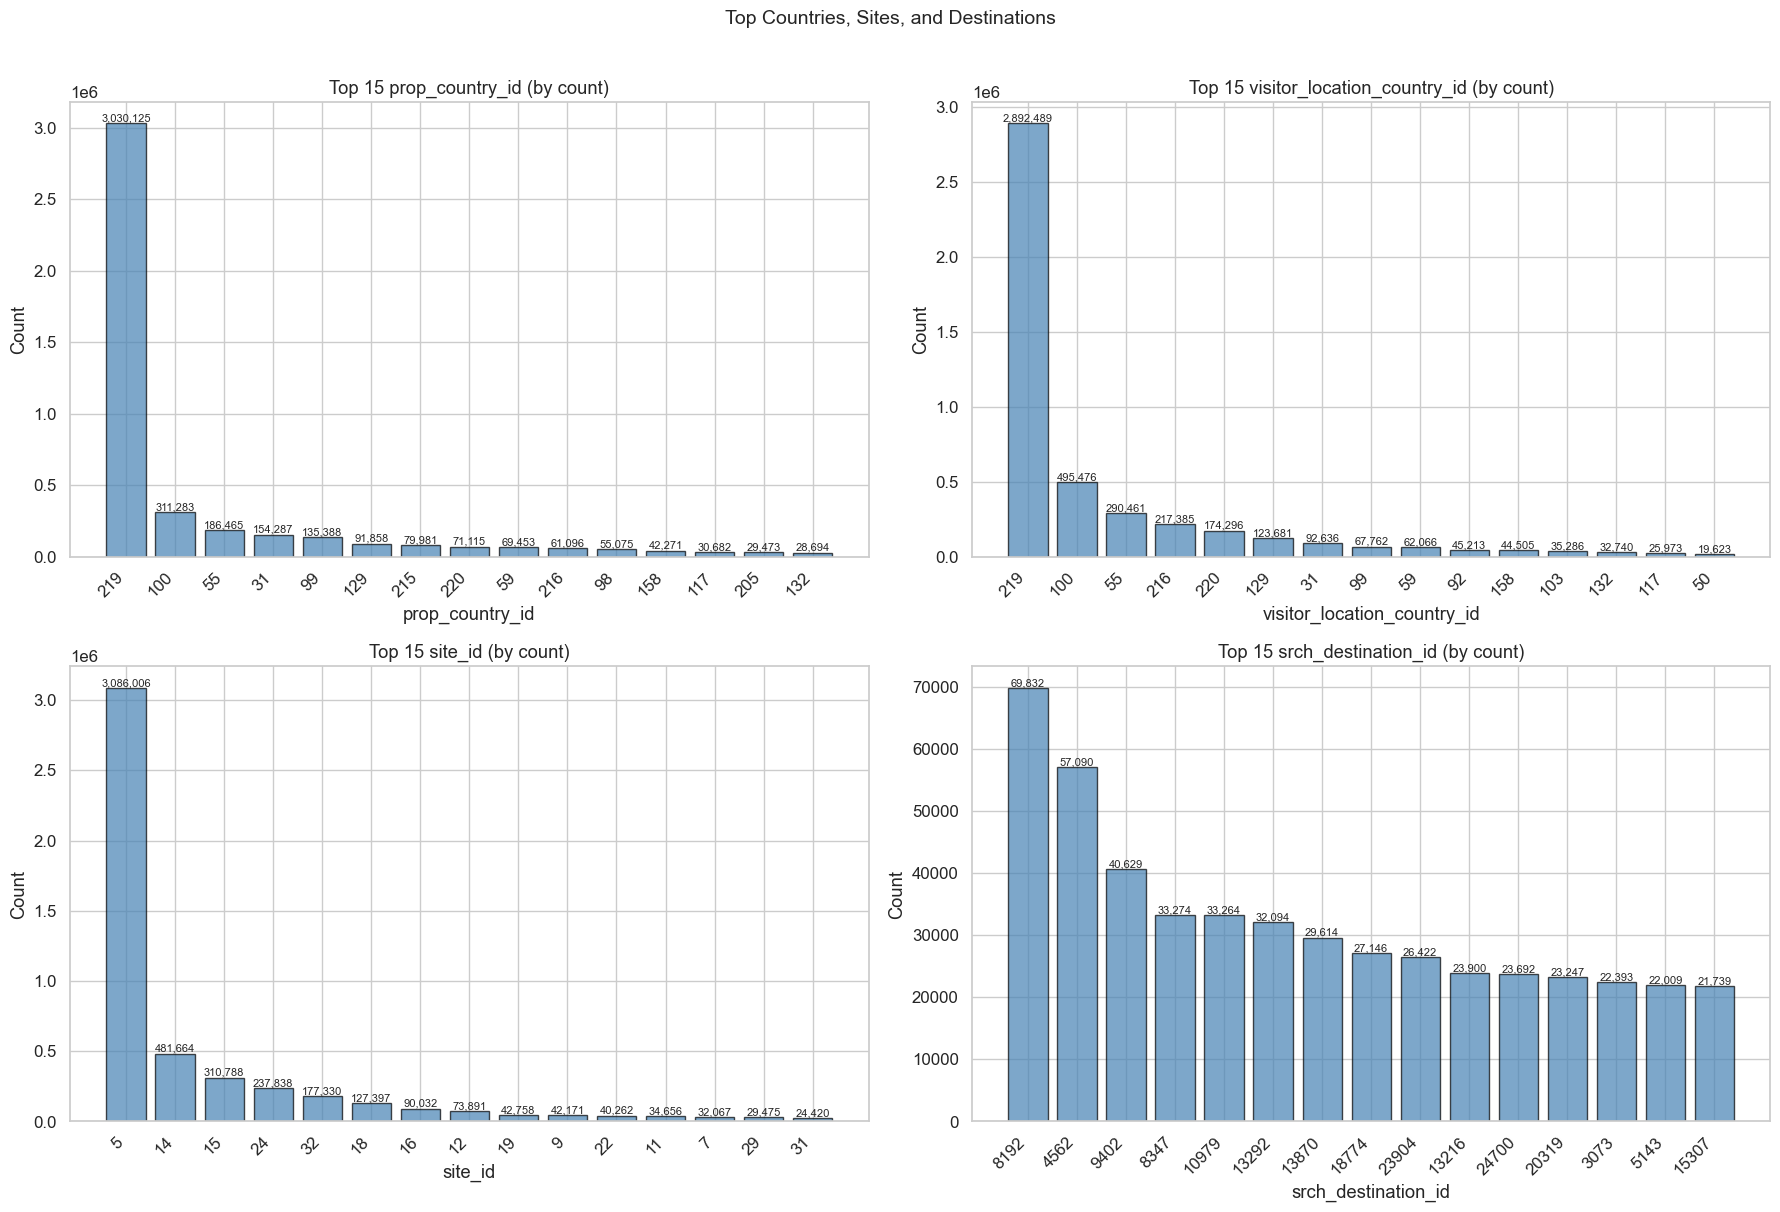

prop_country_id: 172 unique values
visitor_location_country_id: 210 unique values
site_id: 34 unique values
srch_destination_id: 18,127 unique values


In [22]:
# Top countries/sites/destinations
id_features = ['prop_country_id', 'visitor_location_country_id', 'site_id', 'srch_destination_id']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes_flat = axes.flatten()

for i, col in enumerate(id_features):
    ax = axes_flat[i]
    top15 = train[col].value_counts().head(15)
    bars = ax.bar(range(len(top15)), top15.values, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xticks(range(len(top15)))
    ax.set_xticklabels(top15.index.astype(str), rotation=45, ha='right')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'Top 15 {col} (by count)')
    
    # Annotate counts
    for bar, val in zip(bars, top15.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Top Countries, Sites, and Destinations', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print cardinality summary
for col in id_features:
    print(f"{col}: {train[col].nunique():,} unique values")

### Key Findings - Section 1.6

- **Hotels per search**: Check whether group size is constant (e.g., always ~38 results per query). Constant group size simplifies listwise ranking model design.
- **Property frequency**: Follows a power-law distribution. A small number of popular properties appear in many searches, while most appear rarely. Aggregate statistics for rare properties will be noisy.
- **Cardinality**: prop_country_id and visitor_location_country_id have moderate cardinality (~200). srch_destination_id has very high cardinality (~thousands), making it difficult to use directly as a feature.
- **site_id**: Few unique sites, likely corresponding to different Expedia regional platforms.

## 1.7 Outlier Detection

In [23]:
# IQR-based outlier table for continuous features
print("Computing IQR-based outlier statistics...")
continuous_cols = [col for col in train.columns 
                   if pd.api.types.is_numeric_dtype(train[col]) 
                   and train[col].nunique() > 10
                   and col not in ['srch_id', 'prop_id', 'site_id', 'date_time_parsed']]

outlier_rows = []
for col in continuous_cols:
    data = train[col].dropna()
    if len(data) == 0:
        continue
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    below = (data < lower_fence).sum()
    above = (data > upper_fence).sum()
    total_outliers = below + above
    pct_outliers = total_outliers / len(data) * 100
    
    outlier_rows.append({
        'column': col,
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'lower_fence': round(lower_fence, 4),
        'upper_fence': round(upper_fence, 4),
        'n_below': below,
        'n_above': above,
        'pct_outliers': round(pct_outliers, 2),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('pct_outliers', ascending=False)

def highlight_high_outliers(row):
    if row['pct_outliers'] > 10:
        return ['background-color: #ffcccc'] * len(row)
    elif row['pct_outliers'] > 5:
        return ['background-color: #ffffb3'] * len(row)
    return [''] * len(row)

outlier_df.style.apply(highlight_high_outliers, axis=1).set_caption(
    "IQR-Based Outlier Detection (red = >10%, yellow = >5%)")

Computing IQR-based outlier statistics...


,column,Q1,Q3,IQR,lower_fence,upper_fence,n_below,n_above,pct_outliers
6,prop_log_historical_price,4.450000,5.310000,0.860000,3.160000,6.600000,715654,0,14.430000
13,orig_destination_distance,139.800000,1500.670000,1360.870000,-1901.505000,3541.975000,0,417607,12.460000
14,comp1_rate_percent_diff,7.000000,16.000000,9.000000,-6.500000,29.500000,0,8929,9.450000
22,gross_bookings_usd,124.000000,429.790000,305.790000,-334.685000,888.475000,0,12115,8.750000
11,srch_booking_window,4.000000,48.000000,44.000000,-62.000000,114.000000,0,423510,8.540000
16,comp3_rate_percent_diff,7.000000,18.000000,11.000000,-9.500000,34.500000,0,37915,8.020000
19,comp6_rate_percent_diff,6.000000,18.000000,12.000000,-12.000000,36.000000,0,7690,8.000000
20,comp7_rate_percent_diff,7.000000,20.000000,13.000000,-12.500000,39.500000,0,10537,7.610000
17,comp4_rate_percent_diff,7.000000,19.000000,12.000000,-11.000000,37.000000,0,9820,7.490000
15,comp2_rate_percent_diff,7.000000,20.000000,13.000000,-12.500000,39.500000,0,41432,7.450000


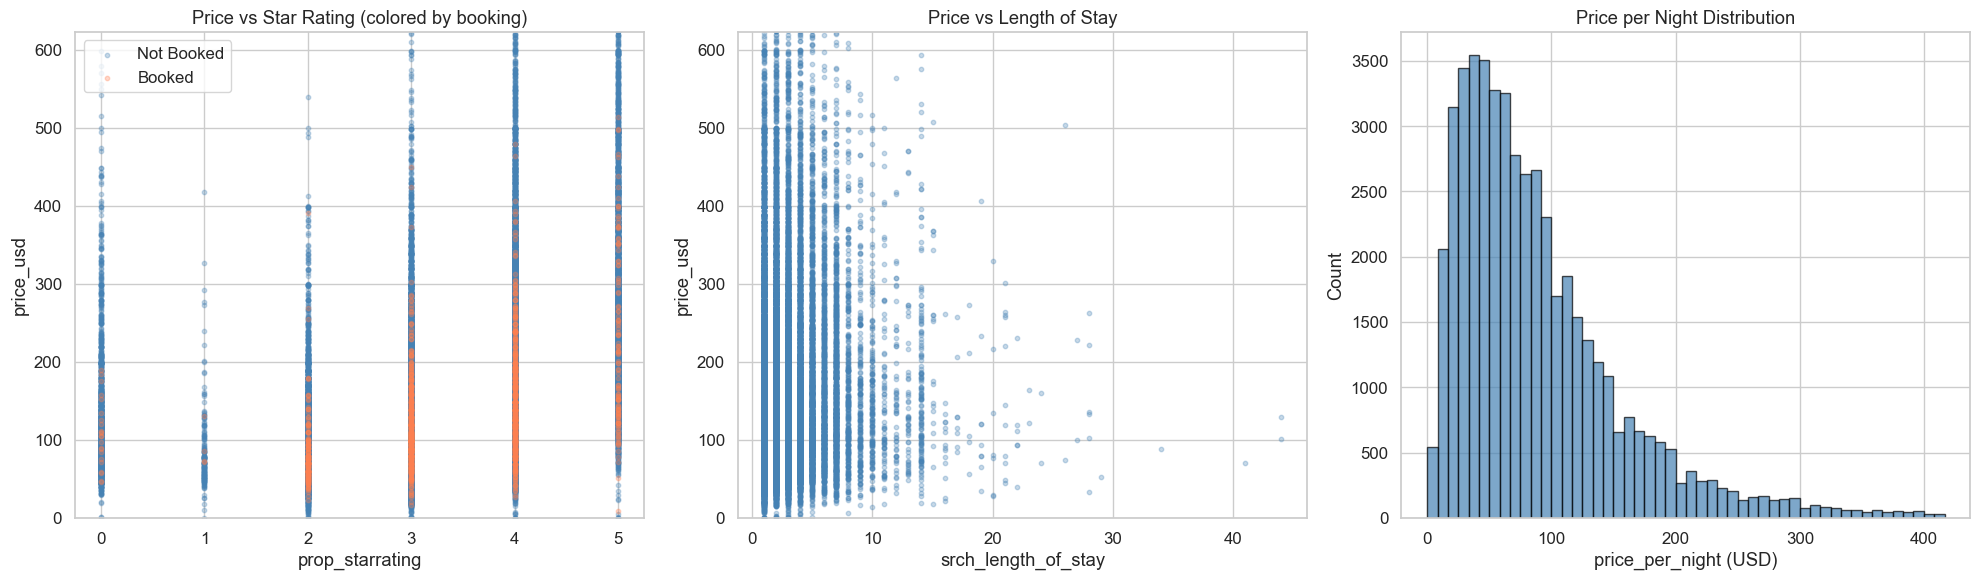

In [24]:
# Price outlier investigation (3 panels)
# Use 1% sample for scatter plots
scatter_sample = train.sample(frac=0.01, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: price_usd vs prop_starrating, colored by booking_bool
ax = axes[0]
booked = scatter_sample[scatter_sample['booking_bool'] == 1]
not_booked = scatter_sample[scatter_sample['booking_bool'] == 0]
ax.scatter(not_booked['prop_starrating'], not_booked['price_usd'], 
           alpha=0.3, s=10, color='steelblue', label='Not Booked')
ax.scatter(booked['prop_starrating'], booked['price_usd'], 
           alpha=0.3, s=10, color='coral', label='Booked')
ax.set_xlabel('prop_starrating')
ax.set_ylabel('price_usd')
ax.set_title('Price vs Star Rating (colored by booking)')
ax.legend()
ax.set_ylim(0, scatter_sample['price_usd'].quantile(0.99))

# Panel 2: price_usd vs srch_length_of_stay
ax = axes[1]
ax.scatter(scatter_sample['srch_length_of_stay'], scatter_sample['price_usd'], 
           alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('srch_length_of_stay')
ax.set_ylabel('price_usd')
ax.set_title('Price vs Length of Stay')
ax.set_ylim(0, scatter_sample['price_usd'].quantile(0.99))

# Panel 3: Histogram of price_per_night
ax = axes[2]
scatter_sample_ppn = scatter_sample.copy()
scatter_sample_ppn['price_per_night'] = scatter_sample_ppn['price_usd'] / scatter_sample_ppn['srch_length_of_stay'].clip(lower=1)
ppn_data = scatter_sample_ppn['price_per_night'].dropna()
ppn_data_clipped = ppn_data[ppn_data <= ppn_data.quantile(0.99)]
ax.hist(ppn_data_clipped, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('price_per_night (USD)')
ax.set_ylabel('Count')
ax.set_title('Price per Night Distribution')

plt.tight_layout()
plt.show()

=== gross_bookings_usd vs price_usd * srch_length_of_stay ===


R-squared (gross_bookings_usd vs price_usd * length_of_stay): -4101.9449


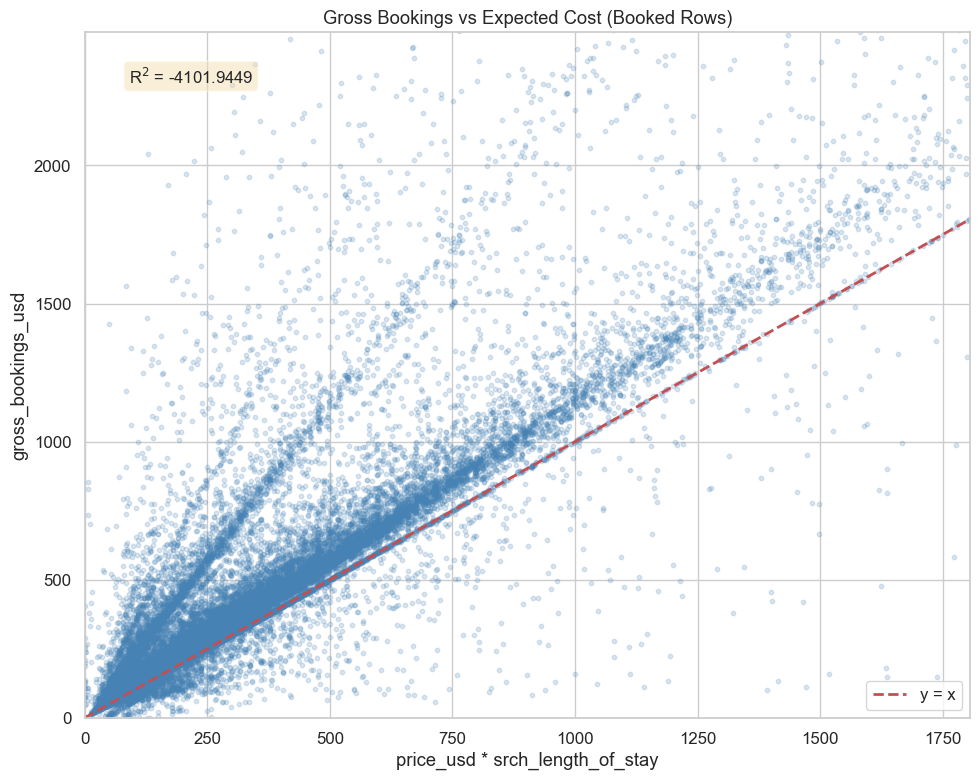

In [25]:
# gross_bookings_usd vs price_usd * srch_length_of_stay for booked rows
print("=== gross_bookings_usd vs price_usd * srch_length_of_stay ===")
booked_all = train[train['booking_bool'] == 1].copy()
booked_all['expected_cost'] = booked_all['price_usd'] * booked_all['srch_length_of_stay'].clip(lower=1)

# Filter out extreme values for cleaner scatter
booked_clean = booked_all[
    (booked_all['gross_bookings_usd'].notna()) & 
    (booked_all['expected_cost'] > 0) & 
    (booked_all['gross_bookings_usd'] > 0)
].copy()

# Use a sample if too large
if len(booked_clean) > 50000:
    booked_scatter = booked_clean.sample(50000, random_state=SEED)
else:
    booked_scatter = booked_clean

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(booked_scatter['expected_cost'], booked_scatter['gross_bookings_usd'], 
           alpha=0.2, s=10, color='steelblue')

# Add diagonal y=x line
max_val = max(booked_scatter['expected_cost'].max(), booked_scatter['gross_bookings_usd'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='y = x')

ax.set_xlabel('price_usd * srch_length_of_stay')
ax.set_ylabel('gross_bookings_usd')
ax.set_title('Gross Bookings vs Expected Cost (Booked Rows)')
ax.legend()

# Clip axes for readability
q99_x = booked_scatter['expected_cost'].quantile(0.99)
q99_y = booked_scatter['gross_bookings_usd'].quantile(0.99)
ax.set_xlim(0, q99_x)
ax.set_ylim(0, q99_y)

# Compute R-squared
from sklearn.metrics import r2_score
mask = booked_clean['expected_cost'].notna() & booked_clean['gross_bookings_usd'].notna()
if mask.sum() > 10:
    r2 = r2_score(booked_clean.loc[mask, 'gross_bookings_usd'], 
                  booked_clean.loc[mask, 'expected_cost'])
    print(f"R-squared (gross_bookings_usd vs price_usd * length_of_stay): {r2:.4f}")
    ax.text(0.05, 0.95, f'R$^2$ = {r2:.4f}', transform=ax.transAxes, 
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### Key Findings - Section 1.7

- **IQR outliers**: Several features have high outlier percentages, especially price-related and distance columns. These heavy tails suggest that log-transforms or clipping may be needed.
- **Price vs star rating**: Higher star ratings tend to have higher median prices. Extreme outlier prices appear at all star levels, possibly data errors or luxury suites.
- **Price vs length of stay**: price_usd appears to be total stay price (not per night), since it increases with length of stay.
- **gross_bookings_usd**: Should approximate price_usd * srch_length_of_stay for booked rows. The R-squared indicates how well this relationship holds. Discrepancies could indicate taxes, fees, currency conversion, or data quality issues.

## 1.8 Temporal Patterns

Computing daily search counts...


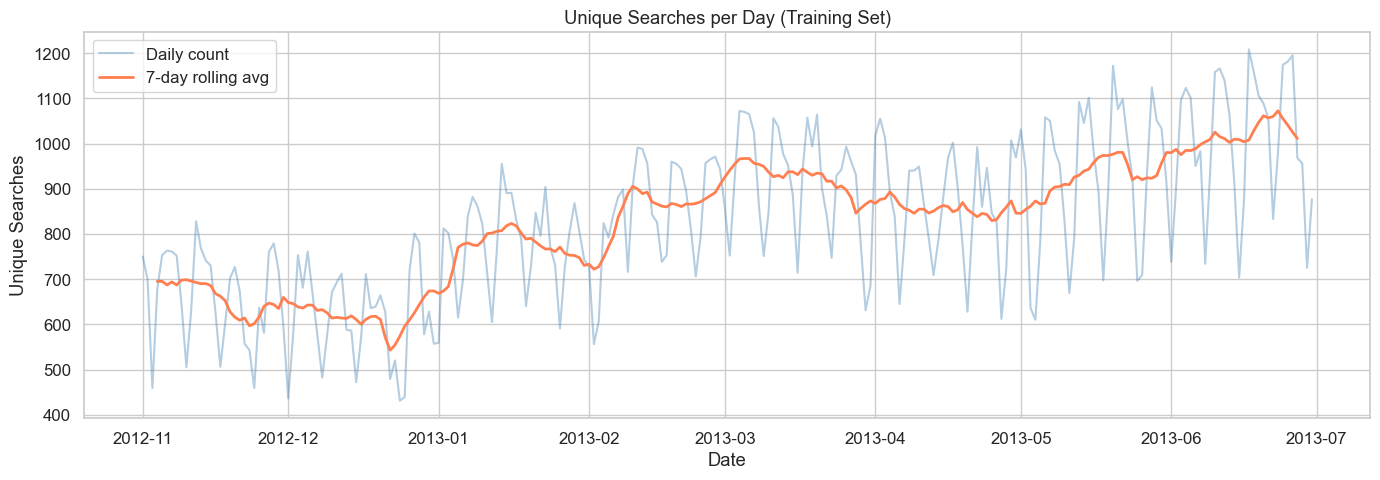

In [26]:
# Searches per day with 7-day rolling average
print("Computing daily search counts...")
train['date'] = train['date_time_parsed'].dt.date
daily_searches = train.groupby('date')['srch_id'].nunique().reset_index()
daily_searches.columns = ['date', 'n_searches']
daily_searches['date'] = pd.to_datetime(daily_searches['date'])
daily_searches = daily_searches.sort_values('date')
daily_searches['rolling_7d'] = daily_searches['n_searches'].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_searches['date'], daily_searches['n_searches'], alpha=0.4, 
        color='steelblue', label='Daily count')
ax.plot(daily_searches['date'], daily_searches['rolling_7d'], 
        color='coral', linewidth=2, label='7-day rolling avg')
ax.set_xlabel('Date')
ax.set_ylabel('Unique Searches')
ax.set_title('Unique Searches per Day (Training Set)')
ax.legend()
plt.tight_layout()
plt.show()

Computing click/booking rates by hour...


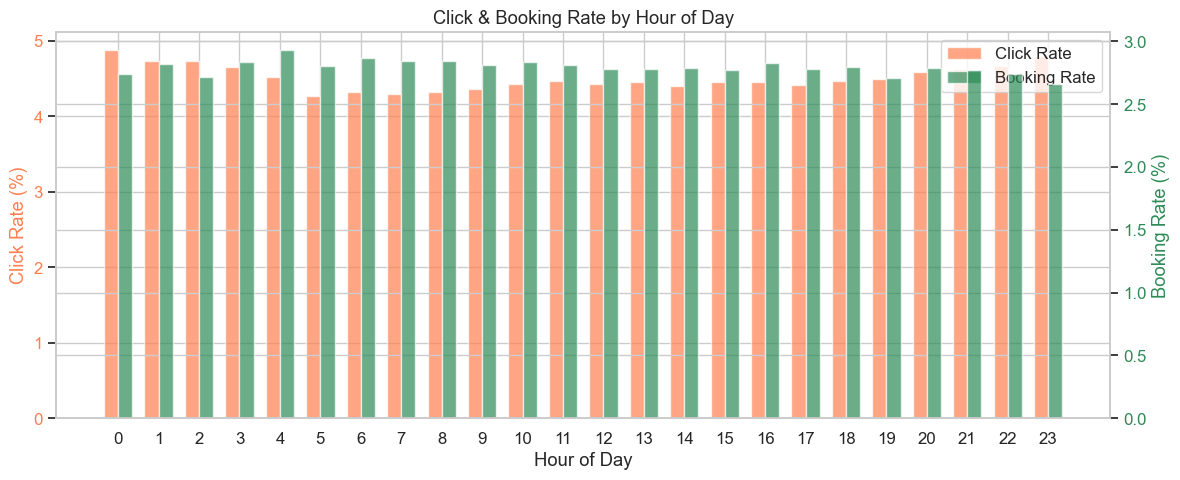

In [27]:
# Click/booking rate by hour
print("Computing click/booking rates by hour...")
train['hour'] = train['date_time_parsed'].dt.hour
hourly_rates = train.groupby('hour').agg(
    click_rate=('click_bool', 'mean'),
    booking_rate=('booking_bool', 'mean')
).reset_index()
hourly_rates['click_rate'] *= 100
hourly_rates['booking_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(12, 5))
color1 = 'coral'
color2 = 'seagreen'
x = hourly_rates['hour']
width = 0.35

bars1 = ax1.bar(x - width/2, hourly_rates['click_rate'], width, color=color1, alpha=0.7, label='Click Rate')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Click Rate (%)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, hourly_rates['booking_rate'], width, color=color2, alpha=0.7, label='Booking Rate')
ax2.set_ylabel('Booking Rate (%)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('Click & Booking Rate by Hour of Day')
ax1.set_xticks(range(24))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

Computing click/booking rates by day of week...


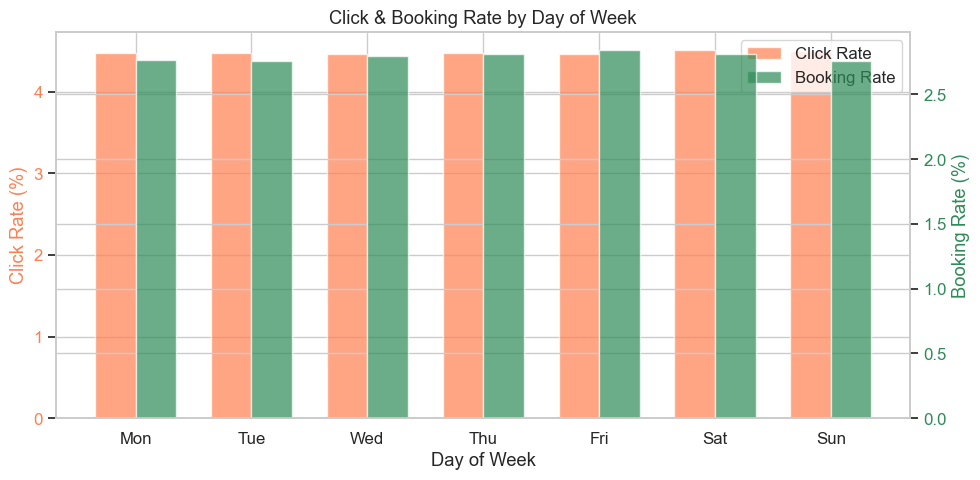

In [28]:
# Click/booking rate by day of week
print("Computing click/booking rates by day of week...")
train['dayofweek'] = train['date_time_parsed'].dt.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

dow_rates = train.groupby('dayofweek').agg(
    click_rate=('click_bool', 'mean'),
    booking_rate=('booking_bool', 'mean')
).reset_index()
dow_rates['click_rate'] *= 100
dow_rates['booking_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(10, 5))
x = dow_rates['dayofweek']
width = 0.35

bars1 = ax1.bar(x - width/2, dow_rates['click_rate'], width, color='coral', alpha=0.7, label='Click Rate')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Click Rate (%)', color='coral')
ax1.tick_params(axis='y', labelcolor='coral')
ax1.set_xticks(range(7))
ax1.set_xticklabels(day_names)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, dow_rates['booking_rate'], width, color='seagreen', alpha=0.7, label='Booking Rate')
ax2.set_ylabel('Booking Rate (%)', color='seagreen')
ax2.tick_params(axis='y', labelcolor='seagreen')

ax1.set_title('Click & Booking Rate by Day of Week')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

Computing click/booking rates by month...


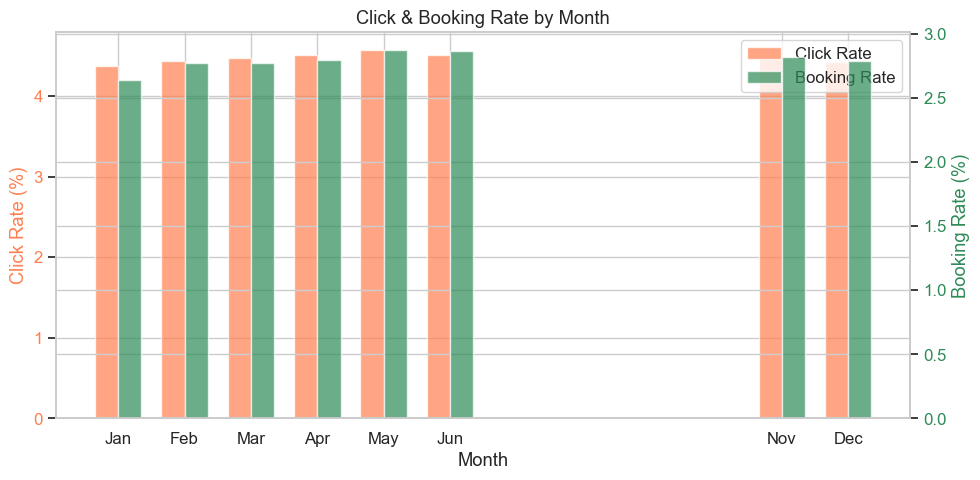

In [29]:
# Click/booking rate by month
print("Computing click/booking rates by month...")
train['month'] = train['date_time_parsed'].dt.month

month_rates = train.groupby('month').agg(
    click_rate=('click_bool', 'mean'),
    booking_rate=('booking_bool', 'mean')
).reset_index()
month_rates['click_rate'] *= 100
month_rates['booking_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(10, 5))
x = month_rates['month']
width = 0.35

bars1 = ax1.bar(x - width/2, month_rates['click_rate'], width, color='coral', alpha=0.7, label='Click Rate')
ax1.set_xlabel('Month')
ax1.set_ylabel('Click Rate (%)', color='coral')
ax1.tick_params(axis='y', labelcolor='coral')
ax1.set_xticks(month_rates['month'])
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.set_xticklabels([month_labels[m-1] for m in month_rates['month']])

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, month_rates['booking_rate'], width, color='seagreen', alpha=0.7, label='Booking Rate')
ax2.set_ylabel('Booking Rate (%)', color='seagreen')
ax2.tick_params(axis='y', labelcolor='seagreen')

ax1.set_title('Click & Booking Rate by Month')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

Computing average price by month...


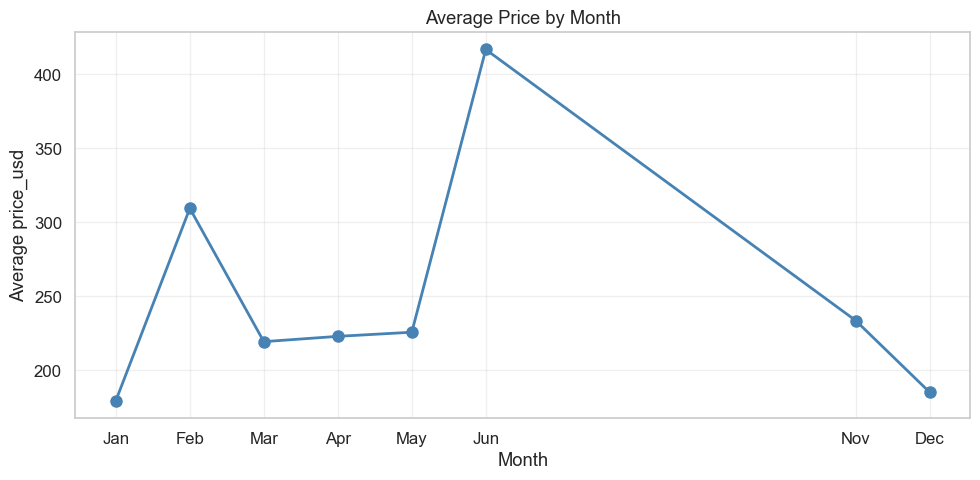

In [30]:
# Average price by month
print("Computing average price by month...")
monthly_price = train.groupby('month')['price_usd'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_price['month'], monthly_price['price_usd'], 
        marker='o', linewidth=2, color='steelblue', markersize=8)
ax.set_xlabel('Month')
ax.set_ylabel('Average price_usd')
ax.set_title('Average Price by Month')
ax.set_xticks(monthly_price['month'])
ax.set_xticklabels([month_labels[m-1] for m in monthly_price['month']])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings - Section 1.8

- **Search volume**: Look for weekly seasonality (dips on weekends?), trends over time, and any anomalous periods.
- **Hourly patterns**: Click and booking rates may vary by time of day. Users searching at certain hours may have higher intent.
- **Day-of-week patterns**: Weekday vs weekend behavior differences could be used as features.
- **Monthly patterns**: Seasonal pricing variations and booking rate changes indicate that month/season could be a useful feature.
- **Temporal features**: Consider extracting hour, day_of_week, month, and is_weekend as model features.

---

## Final Summary

### Data Structure
- The dataset contains ~5M rows each for train and test, with ~50 columns covering search context, property attributes, competitor pricing, and visitor history.
- Each row represents one property shown in one search. Searches (srch_id) contain multiple candidate properties.
- Train-only columns: position, click_bool, booking_bool, gross_bookings_usd.
- The target for ranking is a relevance label derived from click_bool and booking_bool.

### Missing Values
- **Competitor columns** (comp1-8 rate/inv/rate_percent_diff) are >90% missing -- most searches do not have competitor pricing data.
- **Visitor history** (visitor_hist_starrating, visitor_hist_adr_usd) are missing for first-time visitors (~50-60% missing).
- **srch_query_affinity_score** has substantial missingness.
- Missingness is often **informative** -- the fact that a value is missing can itself predict click/booking behavior. Binary `is_missing` features should be considered.

### Distributions
- **price_usd** is heavily right-skewed with extreme outliers. Log-transformation is recommended.
- **Star rating and review score** have clear discrete distributions. Value 0 likely means "unrated."
- **Search parameters**: Most searches are for short stays (1-3 nights), 1-2 adults, single rooms.
- **orig_destination_distance** spans many orders of magnitude (log-normal).

### Temporal Behavior
- Search volume shows weekly seasonality and potential trends.
- Click/booking rates vary by hour, day of week, and month -- temporal features have predictive value.
- Average prices show seasonal variation.

### Key Modeling Implications
1. **Position bias**: When random_bool=0, results were ordered by Expedia's algorithm, creating position bias. Consider debiasing strategies.
2. **Missing value handling**: Use `is_missing` indicators for informative missingness. Imputation strategies should be column-specific.
3. **Feature engineering priorities**: Price normalization (log, per-night), competitor aggregation (n_competitors_cheaper, avg_rate_diff), temporal features, visitor history matching.
4. **Property overlap**: Most test properties appear in training, supporting property-level aggregate features. Fallback needed for unseen properties.

## 1.9 Cold-Start & ID Overlap Analysis (Expanded)

Beyond prop_id overlap, check cross-entity overlaps that affect aggregate feature coverage.

In [31]:
# Extended cold-start / ID overlap analysis
overlap_checks = {
    "prop_id": ("prop_id",),
    "srch_destination_id": ("srch_destination_id",),
    "site_id": ("site_id",),
    "prop_country_id": ("prop_country_id",),
}

print("=== Train/Test ID Overlap ===")
print(f"{'Entity':<35} {'Train unique':>12} {'Test unique':>12} {'Overlap':>10} {'Test unseen':>12} {'Unseen %':>10}")
print("-" * 95)

for label, cols in overlap_checks.items():
    if all(c in train.columns and c in test.columns for c in cols):
        if len(cols) == 1:
            train_vals = set(train[cols[0]].dropna().unique())
            test_vals = set(test[cols[0]].dropna().unique())
        else:
            train_vals = set(zip(*(train[c].dropna() for c in cols)))
            test_vals = set(zip(*(test[c].dropna() for c in cols)))
        overlap = train_vals & test_vals
        unseen = test_vals - train_vals
        pct = len(unseen) / len(test_vals) * 100 if len(test_vals) > 0 else 0
        print(f"{label:<35} {len(train_vals):>12,} {len(test_vals):>12,} {len(overlap):>10,} {len(unseen):>12,} {pct:>9.1f}%")

# Cross-entity overlaps (higher cardinality — more cold-start)
print("\n=== Cross-Entity Overlap (higher cardinality) ===")
for label, col1, col2 in [
    ("prop_id x destination", "prop_id", "srch_destination_id"),
    ("prop_id x site_id", "prop_id", "site_id"),
]:
    if col1 in train.columns and col2 in train.columns and col1 in test.columns and col2 in test.columns:
        train_pairs = set(zip(train[col1], train[col2]))
        test_pairs = set(zip(test[col1], test[col2]))
        overlap = train_pairs & test_pairs
        unseen = test_pairs - train_pairs
        pct = len(unseen) / len(test_pairs) * 100 if len(test_pairs) > 0 else 0
        print(f"{label:<35} train={len(train_pairs):>10,}  test={len(test_pairs):>10,}  unseen={len(unseen):>10,} ({pct:.1f}%)")

print("\nHigh unseen % means aggregate features for that entity combination will fall back to global prior.")

=== Train/Test ID Overlap ===
Entity                              Train unique  Test unique    Overlap  Test unseen   Unseen %
-----------------------------------------------------------------------------------------------


prop_id                                  129,113      129,438    121,665        7,773       6.0%


srch_destination_id                       18,127       18,049     12,461        5,588      31.0%


site_id                                       34           34         34            0       0.0%


prop_country_id                              172          167        167            0       0.0%

=== Cross-Entity Overlap (higher cardinality) ===


prop_id x destination               train=   610,375  test=   612,744  unseen=   203,230 (33.2%)


prop_id x site_id                   train=   586,811  test=   594,420  unseen=   220,608 (37.1%)

High unseen % means aggregate features for that entity combination will fall back to global prior.


## 1.10 Train/Test Query Group Size Comparison

If test has larger groups, top-5 ranking becomes harder (more candidates to rank).

=== Hotels per Search: Train vs Test ===
Statistic            Train       Test
----------------------------------------
mean                  24.8       24.9
median                29.0       29.0
std                    9.1        9.1
min                    5.0        5.0
max                   38.0       38.0
p25                   18.0       18.0
p75                   32.0       32.0
p90                   33.0       33.0
p95                   34.0       34.0
p99                   35.0       34.0


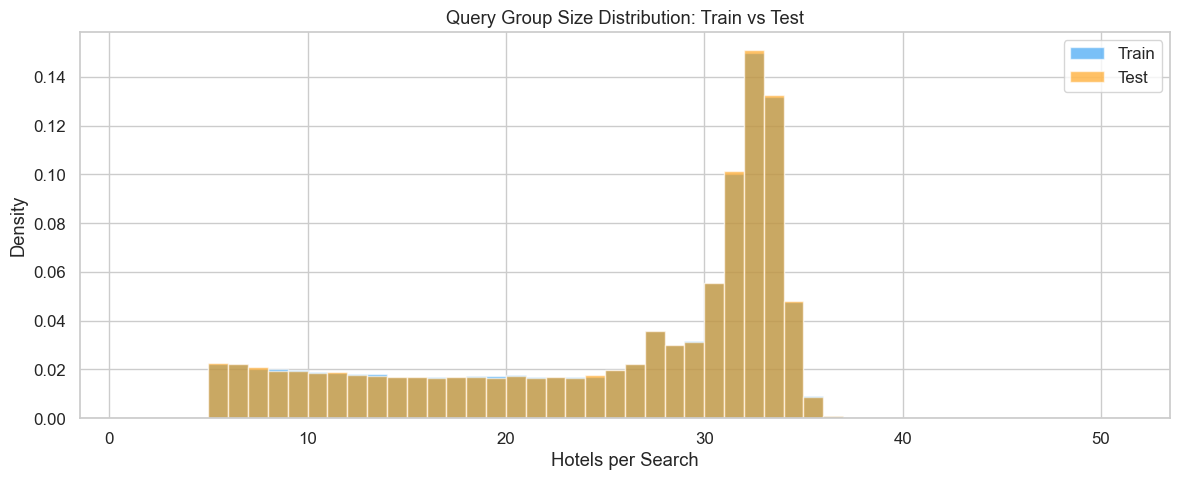

In [32]:
# Group size comparison
train_gs = train.groupby("srch_id").size()
test_gs = test.groupby("srch_id").size()

print("=== Hotels per Search: Train vs Test ===")
print(f"{'Statistic':<15} {'Train':>10} {'Test':>10}")
print("-" * 40)
for stat in ["mean", "median", "std", "min", "max"]:
    tv = getattr(train_gs, stat)() if stat != "median" else train_gs.median()
    sv = getattr(test_gs, stat)() if stat != "median" else test_gs.median()
    print(f"{stat:<15} {tv:>10.1f} {sv:>10.1f}")

# Percentiles
for p in [25, 75, 90, 95, 99]:
    tv = train_gs.quantile(p/100)
    sv = test_gs.quantile(p/100)
    print(f"{'p'+str(p):<15} {tv:>10.1f} {sv:>10.1f}")

# Distribution overlay
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(train_gs.clip(upper=50), bins=range(1, 52), alpha=0.6, label="Train", density=True, color="#2196F3")
ax.hist(test_gs.clip(upper=50), bins=range(1, 52), alpha=0.6, label="Test", density=True, color="#FF9800")
ax.set_xlabel("Hotels per Search")
ax.set_ylabel("Density")
ax.set_title("Query Group Size Distribution: Train vs Test")
ax.legend()
plt.tight_layout()
plt.show()

## 1.11 Missingness as Signal by Segment

Check whether missingness is systematically biased across sites, countries, or random_bool.

In [33]:
# Missingness by segment for key sparse features
sparse_features = ["srch_query_affinity_score", "orig_destination_distance",
                   "visitor_hist_starrating", "visitor_hist_adr_usd"]

# By random_bool
print("=== Missing % by random_bool ===")
print(f"{'Feature':<35} {'random=0':>12} {'random=1':>12} {'Diff':>10}")
print("-" * 75)
for feat in sparse_features:
    if feat in train.columns:
        r0 = train[train["random_bool"]==0][feat].isna().mean() * 100
        r1 = train[train["random_bool"]==1][feat].isna().mean() * 100
        print(f"{feat:<35} {r0:>11.1f}% {r1:>11.1f}% {r0-r1:>9.1f}pp")

# By top sites
print("\n=== Missing % by site_id (top 5 sites) ===")
top_sites = train["site_id"].value_counts().head(5).index
for feat in sparse_features[:2]:
    if feat in train.columns:
        print(f"\n  {feat}:")
        for site in top_sites:
            rate = train[train["site_id"]==site][feat].isna().mean() * 100
            print(f"    site {site}: {rate:.1f}% missing")

# Train vs test missingness drift
print("\n=== Missing % Drift: Train vs Test ===")
print(f"{'Feature':<35} {'Train miss%':>12} {'Test miss%':>12} {'Drift':>10}")
print("-" * 75)
for feat in sparse_features:
    if feat in train.columns and feat in test.columns:
        train_miss = train[feat].isna().mean() * 100
        test_miss = test[feat].isna().mean() * 100
        print(f"{feat:<35} {train_miss:>11.1f}% {test_miss:>11.1f}% {test_miss-train_miss:>9.1f}pp")

# Competitor availability drift
print("\n=== Competitor Missing % Drift ===")
for i in range(1, 9):
    col = f"comp{i}_rate"
    if col in train.columns and col in test.columns:
        tr = train[col].isna().mean() * 100
        te = test[col].isna().mean() * 100
        print(f"  comp{i}_rate: train={tr:.1f}%  test={te:.1f}%  drift={te-tr:+.1f}pp")

# test already in scope

=== Missing % by random_bool ===
Feature                                 random=0     random=1       Diff
---------------------------------------------------------------------------


srch_query_affinity_score                  92.5%        96.3%      -3.8pp


orig_destination_distance                  31.8%        34.0%      -2.2pp


visitor_hist_starrating                    93.9%        97.3%      -3.4pp


visitor_hist_adr_usd                       93.9%        97.3%      -3.4pp

=== Missing % by site_id (top 5 sites) ===

  srch_query_affinity_score:


...

  comp4_rate: train=93.8%  test=93.7%  drift=-0.1pp


  comp5_rate: train=55.2%  test=55.2%  drift=+0.0pp


  comp6_rate: train=95.2%  test=95.1%  drift=-0.0pp


  comp7_rate: train=93.6%  test=93.6%  drift=-0.0pp


  comp8_rate: train=61.3%  test=61.6%  drift=+0.3pp


## 1.12 Adversarial Validation

Train a classifier to distinguish train vs test rows. High AUC means distributional shift — features with high importance are the ones most likely to cause generalization failure.

In [34]:
# Adversarial validation: can a classifier distinguish train from test?
import lightgbm as lgb
# Use shared columns only, exclude IDs and date_time
shared_cols = [c for c in train.select_dtypes(include=[np.number]).columns
               if c in test.columns and c not in ["srch_id", "prop_id"]]

# Sample for speed
np.random.seed(42)
train_idx = np.random.choice(len(train), size=min(200000, len(train)), replace=False)
test_idx = np.random.choice(len(test), size=min(200000, len(test)), replace=False)

X_train_adv = train.iloc[train_idx][shared_cols].copy()
X_test_adv = test.iloc[test_idx][shared_cols].copy()

X_adv = pd.concat([X_train_adv, X_test_adv], ignore_index=True)
y_adv = np.array([0]*len(X_train_adv) + [1]*len(X_test_adv))

# Shuffle and split
from sklearn.model_selection import train_test_split
X_tr, X_va, y_tr, y_va = train_test_split(X_adv, y_adv, test_size=0.3, random_state=42, stratify=y_adv)

dtrain_adv = lgb.Dataset(X_tr, label=y_tr)
dval_adv = lgb.Dataset(X_va, label=y_va, reference=dtrain_adv)

adv_model = lgb.train(
    {"objective": "binary", "metric": "auc", "learning_rate": 0.1,
     "num_leaves": 31, "verbose": -1, "seed": 42},
    dtrain_adv, num_boost_round=100, valid_sets=[dval_adv],
    callbacks=[lgb.log_evaluation(50)]
)

from sklearn.metrics import roc_auc_score
preds_adv = adv_model.predict(X_va)
auc = roc_auc_score(y_va, preds_adv)
print(f"\nAdversarial Validation AUC: {auc:.4f}")
if auc < 0.55:
    print("Low AUC => train and test distributions are similar. Good for generalization.")
elif auc < 0.65:
    print("Moderate AUC => some distribution shift. Watch top-importance features.")
else:
    print("High AUC => significant train/test shift! Top-drifted features may hurt.")

# Top features driving train/test distinction
imp = sorted(zip(shared_cols, adv_model.feature_importance(importance_type="gain")),
             key=lambda x: x[1], reverse=True)
print(f"\nTop 15 features distinguishing train from test (most drifted):")
for feat, gain in imp[:15]:
    print(f"  {feat:<40} gain={gain:,.0f}")

# test already in scope, X_adv, X_tr, X_va

[50]	valid_0's auc: 0.516853


[100]	valid_0's auc: 0.524114



Adversarial Validation AUC: 0.5241
Low AUC => train and test distributions are similar. Good for generalization.

Top 15 features distinguishing train from test (most drifted):
  srch_destination_id                      gain=2,667
  srch_booking_window                      gain=2,624
  orig_destination_distance                gain=2,542
  prop_location_score2                     gain=2,011
  prop_location_score1                     gain=1,612
  price_usd                                gain=1,502
  prop_log_historical_price                gain=1,263
  visitor_hist_adr_usd                     gain=1,011
  srch_length_of_stay                      gain=946
  visitor_location_country_id              gain=894
  prop_country_id                          gain=843
  site_id                                  gain=831
  visitor_hist_starrating                  gain=677
  comp5_rate_percent_diff                  gain=663
  srch_adults_count                        gain=554


### Key Findings - New Sections (1.9-1.12)

- **Cold-start coverage**: Cross-entity overlaps (prop_id x destination) are much lower than individual ID overlap — many test combinations are unseen in training
- **Group sizes**: Train and test should have similar group size distributions; large differences would affect ranking difficulty
- **Missingness drift**: Any significant difference in missing rates between train/test could bias aggregate features
- **Adversarial validation**: AUC near 0.5 means train/test are well-matched; AUC > 0.6 indicates distributional shift requiring caution